In [1]:
import os,sys
sys.path.append(os.path.dirname(os.getcwd()))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
from functools import partial
from typing import Any, Sequence

# activate TPUs if available
try:
    import jax.tools.colab_tpu
    jax.tools.colab_tpu.setup_tpu()
except (KeyError, RuntimeError):
    print("TPU not found, continuing without it.")

from jax import config
config.update("jax_enable_x64", True)

import jax
from jax import numpy as jnp
from jax import random
from jax import vmap
from jax.tree_util import Partial, tree_map

from jaxopt import LBFGS, GradientDescent
from jaxopt import linear_solve
from jaxopt import OptaxSolver
from jaxopt import tree_util

import optax

# we use flax to construct a small multi-layer perceptron
from flax import linen as nn
from tqdm.auto import tqdm

# for plotting
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

TPU not found, continuing without it.


In [3]:
# import scienceplots
# plt.style.use(["science", "grid"])
%matplotlib inline

# Default setting
import matplotlib as mpl
import matplotlib
# import seaborn as sns
from matplotlib import cm
from cycler import cycler

# mpl.rcParams['axes.prop_cycle'] = cycler(color='brgcmyk')
# grid setting
plt.rcParams['axes.grid'] = False
plt.rcParams['grid.color'] = '#808080'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 1.0

# graph font size
# mpl.rcParams['font.size'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['figure.titlesize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

# tight axis
plt.rcParams['axes.xmargin'] = 0

# figure size
plt.rcParams["figure.figsize"] = (6.4, 4.8)

# LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['pdf.fonttype'] = 42 # For TrueType fonts


In [4]:
import jax.numpy as jnp
import jax
import pickle
import time
from jax import hessian, jacobian, jit, vmap, grad, random, value_and_grad
from functools import partial
import diffrax
from typing import Callable, Optional, Union
from flax import linen as nn
from flax.training.train_state import TrainState
import optax
from jax_md.quantity import force
import equinox as eqx
from tqdm import trange, tqdm

In [5]:
from blockymetamaterials.utils import SolutionType, SolutionData, ControlParams, GeometricalParams, MechanicalParams, LigamentParams, ContactParams
from blockymetamaterials.geometry import Geometry, QuadGeometry, compute_inertia, compute_edge_angles, compute_edge_lengths, DOFsInfo, QuadGeometry_InputSource
from blockymetamaterials.energy import build_strain_energy, kinetic_energy, ligament_energy, ligament_energy_linearized, build_contact_energy, combine_block_energies, compute_ligament_strains_history, constrain_energy
from typing import Any, Literal, Optional, List, Union, Tuple, Dict
import dataclasses
from dataclasses import dataclass
from itertools import combinations
from cooptimization_real import setup_dynamic_solver, setup_dynamic_solver_all


In [6]:
color_list = ["#2980b9", "#e74c3c", "#00a043", "#793693", "#f1c40f","#fb9206"]

In [7]:
class minmax_scaler():
  def __init__(self, input_data, output_data):
    # assume that 
    self.data_max = jnp.max(input_data, axis=(0, 1), keepdims=True)
    self.data_min = jnp.min(input_data, axis=(0, 1), keepdims=True)
    print(self.data_max.shape, self.data_min.shape)

    self.output_data_max = jnp.max(output_data, axis=(0, 1), keepdims=True)
    self.output_data_min = jnp.min(output_data, axis=(0, 1), keepdims=True)
    print(self.output_data_max.shape, self.output_data_min.shape)

  def transform(self, input_data, output_data):
    data_normalized = 2.0 * ( input_data - self.data_min ) / ( self.data_max - self.data_min ) - 1.0  # Add a small value to avoid division by zero
    output_normalized = (output_data - self.output_data_min) / (self.output_data_max - self.output_data_min)
    return data_normalized, output_normalized
  
  def inverse_transform(self, data_normalized, output_normalized):
    data_original = (data_normalized + 1.0) * (self.data_max - self.data_min) / 2.0 + self.data_min
    output_original = output_normalized * (self.output_data_max - self.output_data_min) + self.output_data_min
    return data_original, output_original

  def information(self):
    print("data min : ", self.data_min)
    print("data max : ", self.data_max)
    print("test data min : ", self.output_data_min)
    print("test data max : ", self.output_data_max)
    return self.data_min, self.data_max, self.output_data_min, self.output_data_max

class TimeSeriesCNN(nn.Module):
    features: int = 64
    output_features: int = 2

    @nn.compact
    def __call__(self, x):
        # Input shape: (batch_size, time_steps, 2)
        x = nn.Conv(self.features, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(self.features, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(self.output_features, kernel_size=(1,), padding='SAME')(x)  # Final output: 2 channels
        return x  # Shape: (batch_size, time_steps, 2)
    

In [9]:
from blockymetamaterials.geometry import Geometry, QuadGeometry, compute_inertia, compute_edge_angles, compute_edge_lengths, DOFsInfo, QuadGeometry_Circle_InputSource, polygon_area, polygon_polar_moment
n1_blocks = 15
n2_blocks = 15
n_piece = 8
n_source = n_piece * 2
spacing = 15. + 0.075*15.  # 1.0  # 15 mm
hinge_length = 0.075*15.  # Same as bond length
initial_angle = 25.0*jnp.pi/180

horizontal_shifts, vertical_shifts = QuadGeometry_Circle_InputSource(n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_piece=n_piece).get_design_from_rotated_square(
    angle=initial_angle,
)  # Initial design

# use previous parameters
# Mechanical params
k_stretch = 120.  # stretching stiffness 120. N/mm
k_shear = 1.19  # shearing stiffness 1.19 N/mm
k_rot = 1.50  # rotational stiffness 1.50 Nmm
density = 6.18e-9  # Mg/mm^2


# Dynamic loading (I don't use these parameters)----------
amplitude = 0.5 * spacing  # 0.5 * spacing default 
loading_rate = 30.0 # jnp.array([30., 0., 20., 20., 20.])  #  Hz loading frequency for dynamic input
input_delay = 0.1*30.0**-1 * jnp.ones((n1_blocks,))
#---------------------------------------------------------
min_angle=-15*jnp.pi/180
cutoff_angle=-10*jnp.pi/180

simulation_time = 1.0
n_timepoints = 200
ts = jnp.linspace(0, simulation_time, n_timepoints)
bond_length = hinge_length
linearized_strains = False
use_contact = False
k_contact = k_rot

geometry = QuadGeometry_Circle_InputSource(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=bond_length
)

block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()
_bond_connectivity = bond_connectivity()  # Compute bond connectivity once as it is constant
_reference_bond_vectors = reference_bond_vectors(horizontal_shifts, vertical_shifts)  # Compute reference bond vectors once as they are constant


# key = random.PRNGKey(0)
# N = 300


# with open(f"122525_circular_structure_dataset_n1_blocks_{n1_blocks}_n2_blocks_{n2_blocks}_n_source_8.pickle", "rb") as f:
#     data_dict = pickle.load(f)
# input_data = data_dict["input_data"]
# output_data = data_dict["output_data"]

# test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
# test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

# mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

# training_input_data = input_data[mask]
# training_output_data = output_data[mask]

# test_input_data = input_data[test_idx]
# test_output_data = output_data[test_idx]

# print("input data size : ", input_data.shape)
# print("output data size : ", output_data.shape)

# mm_scaler = minmax_scaler(training_input_data, training_output_data)
# train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
# test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

# model = TimeSeriesCNN(output_features=n_source)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


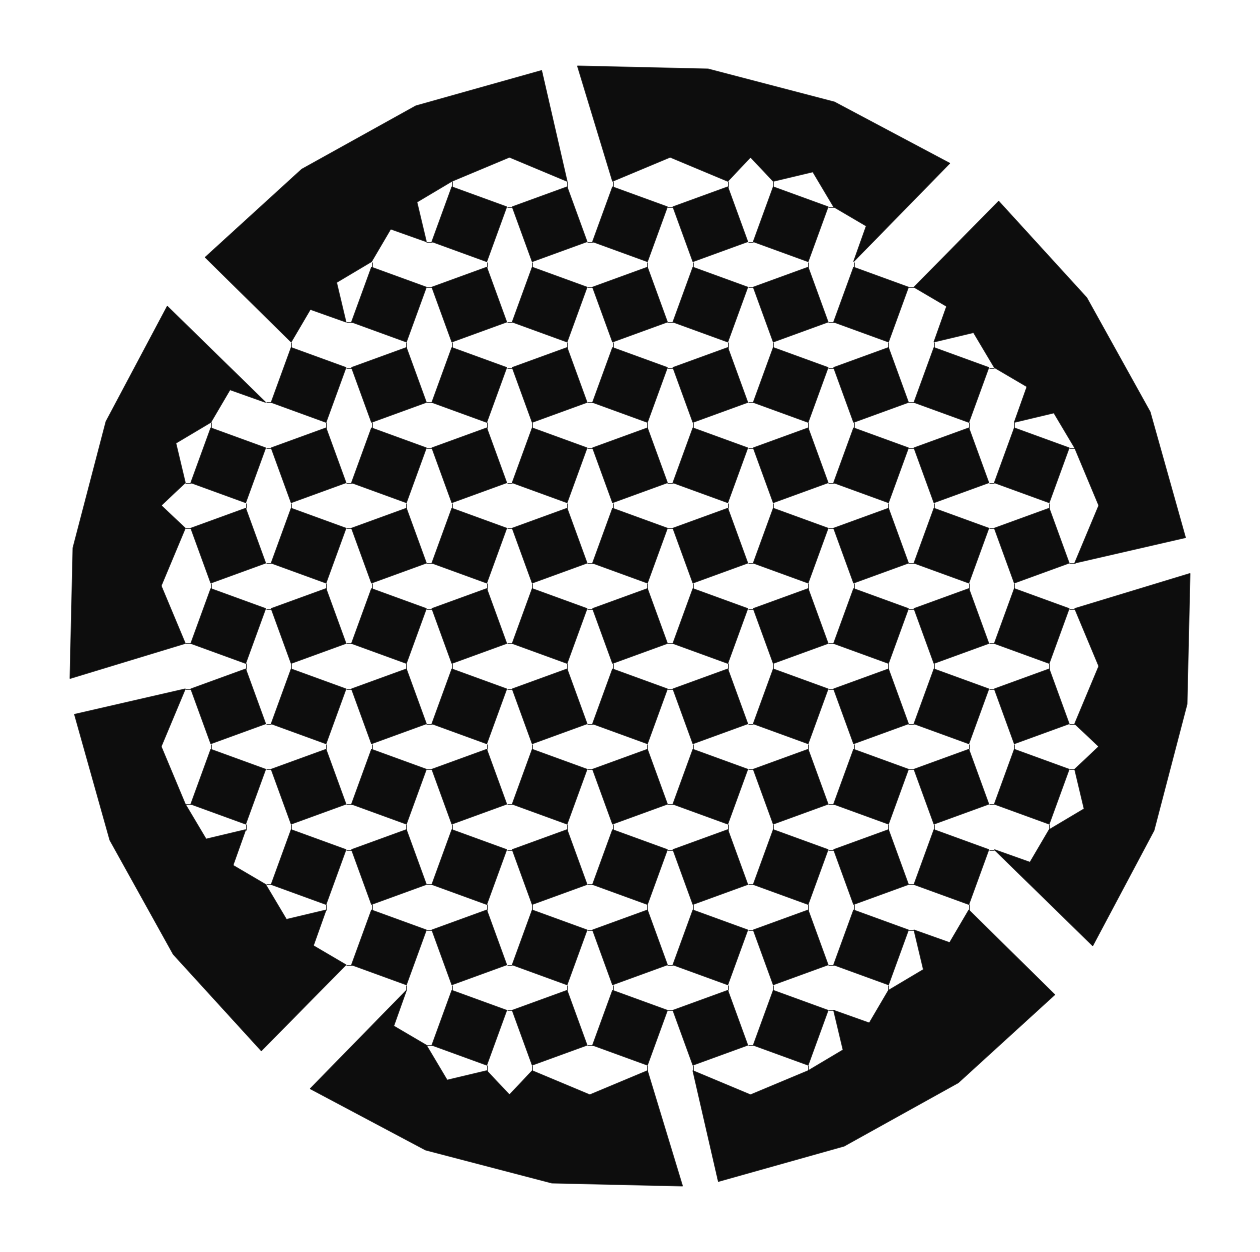

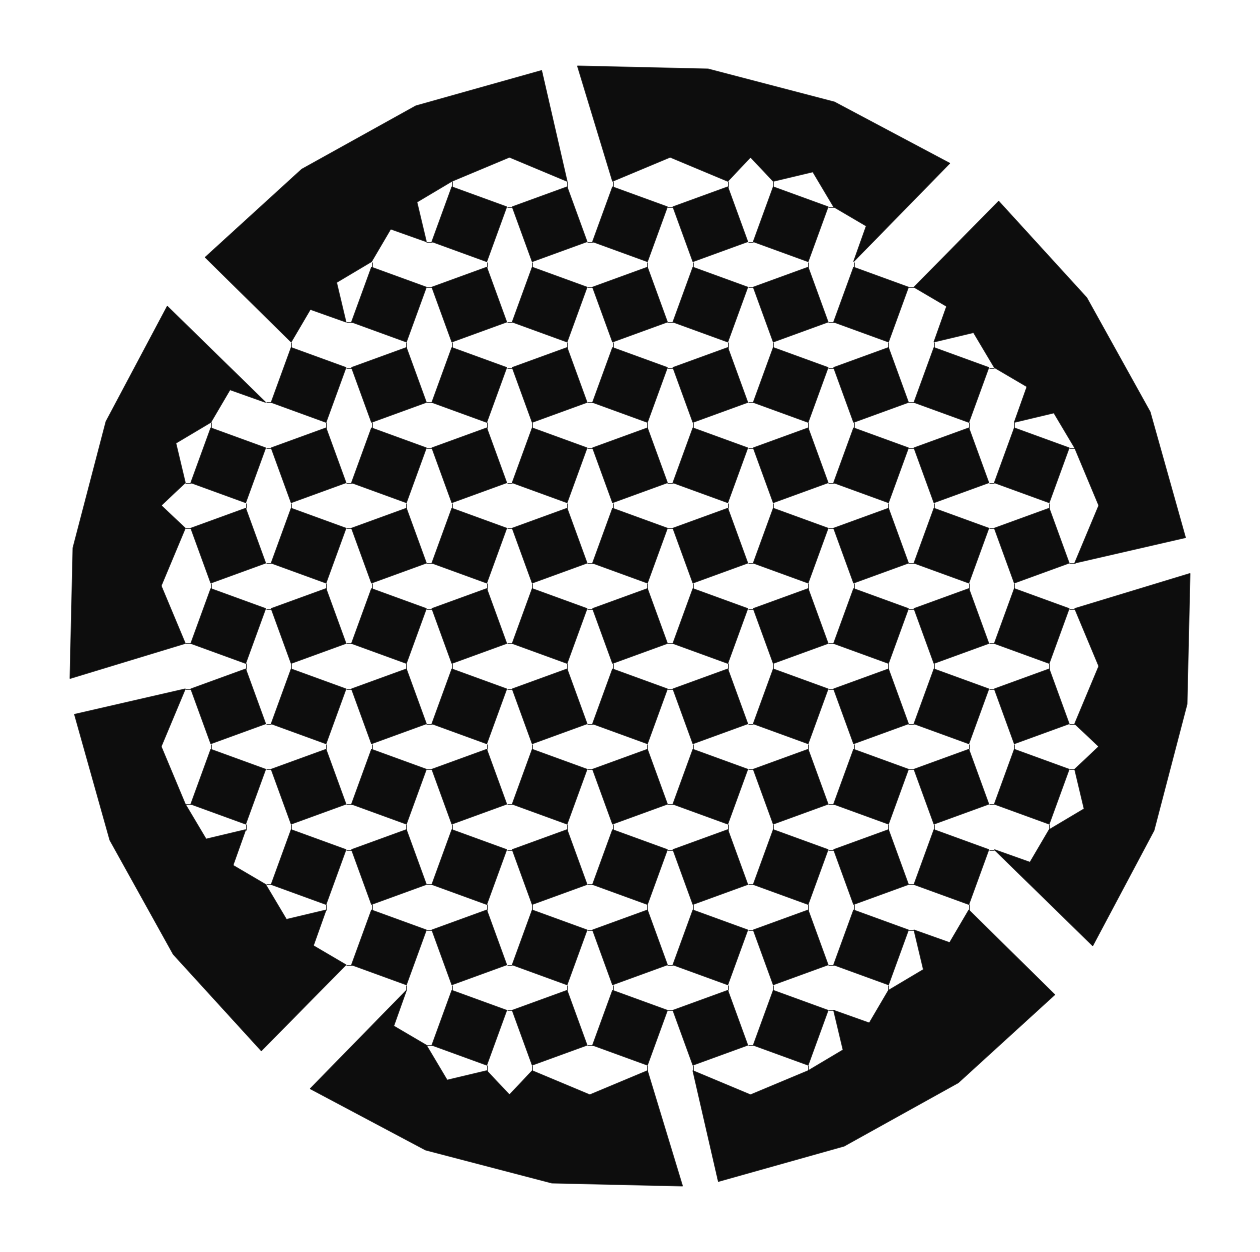

In [10]:
from blockymetamaterials.plotting_input import plot_geometry, compute_xy_limits

design_values = (horizontal_shifts, vertical_shifts)
block_centroids_temp = block_centroids(horizontal_shifts, vertical_shifts)
centroid_node_vectors_temp = centroid_node_vectors(horizontal_shifts, vertical_shifts)

shell_verts = jnp.concatenate([ centroids + vertices for centroids, vertices in zip(centroid_node_vectors_temp, centroid_node_vectors_temp)], axis=0)
# from blockymetamaterials.plotting import generate_animation
# solution = input_data
xlim, ylim = compute_xy_limits(
    shell_verts) + 0.5*geometry.spacing * jnp.array([-1, 1])

fig, ax = plt.subplots(figsize=(16,16))
block_idx = jnp.concatenate( (geometry.blocks_inside, jnp.arange(geometry.n_quads, geometry.n_quads+geometry.n_piece)), dtype=int  )
colors = 'k'
plot_geometry(block_centroids_temp,
              centroid_node_vectors_temp,
              _bond_connectivity,
              color=colors, ax=ax)
ax.axis("equal")
ax.axis("off")
plt.savefig(f"Figure/122525_circular_structure_design_n1_blocks_{n1_blocks}_n2_blocks_{n2_blocks}_n_source_{n_source}.eps")
plt.show()

## Compare results

In [10]:
class minmax_scaler():
  def __init__(self, input_data, output_data):
    # assume that 
    self.data_max = jnp.max(input_data, axis=(0, 1), keepdims=True)
    self.data_min = jnp.min(input_data, axis=(0, 1), keepdims=True)
    print(self.data_max.shape, self.data_min.shape)

    self.output_data_max = jnp.max(output_data, axis=(0, 1), keepdims=True)
    self.output_data_min = jnp.min(output_data, axis=(0, 1), keepdims=True)
    print(self.output_data_max.shape, self.output_data_min.shape)

  def transform(self, input_data, output_data):
    data_normalized = 2.0 * ( input_data - self.data_min ) / ( self.data_max - self.data_min ) - 1.0  # Add a small value to avoid division by zero
    output_normalized = (output_data - self.output_data_min) / (self.output_data_max - self.output_data_min)
    return data_normalized, output_normalized
  
  def inverse_transform(self, data_normalized, output_normalized):
    data_original = (data_normalized + 1.0) * (self.data_max - self.data_min) / 2.0 + self.data_min
    output_original = output_normalized * (self.output_data_max - self.output_data_min) + self.output_data_min
    return data_original, output_original

  def information(self):
    print("data min : ", self.data_min)
    print("data max : ", self.data_max)
    print("test data min : ", self.output_data_min)
    print("test data max : ", self.output_data_max)
    return self.data_min, self.data_max, self.output_data_min, self.output_data_max
    
class TimeSeriesCNN(nn.Module):
    features: int = 64
    output_features: int = 2

    @nn.compact
    def __call__(self, x):
        # Input shape: (batch_size, time_steps, 2)
        x = nn.Conv(self.features, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(self.features, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(self.output_features, kernel_size=(1,), padding='SAME')(x)  # Final output: 2 channels
        return x  # Shape: (batch_size, time_steps, 2)


In [ ]:
# check gradient norm in previous 

from blockymetamaterials.utils import SolutionType, SolutionData, ControlParams, GeometricalParams, MechanicalParams, LigamentParams, ContactParams
# from blockymetamaterials.geometry import Geometry, QuadGeometry, compute_inertia, compute_edge_angles, compute_edge_lengths, DOFsInfo, QuadGeometry_Circle_InputSource, polygon_area, polygon_polar_moment
from blockymetamaterials.geometry import Geometry, QuadGeometry, compute_inertia, compute_edge_angles, compute_edge_lengths, DOFsInfo, QuadGeometry_Circle_InputSource, polygon_area, polygon_polar_moment
from blockymetamaterials.energy import build_strain_energy, kinetic_energy, ligament_energy, ligament_energy_linearized, build_contact_energy, combine_block_energies, compute_ligament_strains_history, constrain_energy
from typing import Any, Literal, Optional, List, Union, Tuple, Dict
import dataclasses
from dataclasses import dataclass
from itertools import combinations
from cooptimization import setup_dynamic_solver, setup_dynamic_solver_all

import diffrax
from typing import Callable, Optional, Union
from flax import linen as nn
from flax.training.train_state import TrainState
import optax
from jax_md.quantity import force
import equinox as eqx
from tqdm import trange, tqdm

def build_viscous_damping(
        geometry: Geometry,
        damped_DOF_ids: jnp.ndarray,
        free_DOF_ids: jnp.ndarray,
        constrained_DOF_ids: jnp.ndarray,
        all_DOF_ids: jnp.ndarray):

    # This is to ensure correct shape of loading vector when damping is either a scalar or an array of shape (n_damped_blocks, 3)
    reshaping_array = jnp.ones((damped_DOF_ids.shape[0]//3, 3))

    def loading_fn(state, t, damping: jnp.ndarray):
        _, velocity = state
        loading_vector = jnp.zeros((len(all_DOF_ids),))
        loading_vector = loading_vector.at[damped_DOF_ids].set(
            (damping * reshaping_array).reshape(damped_DOF_ids.shape)
        )
        loading_vector = loading_vector[free_DOF_ids]

        return -loading_vector * velocity

    return loading_fn


def build_loading(
        geometry: Geometry,
        loaded_DOF_ids: jnp.ndarray,
        loading_fn: Callable,
        free_DOF_ids: jnp.ndarray,
        constrained_DOF_ids: jnp.ndarray,
        all_DOF_ids: jnp.ndarray):

    def global_loading_fn(state, t, loading_params: Dict):

        loading_vector = jnp.zeros((len(all_DOF_ids),))
        
        loading_vector = loading_vector.at[loaded_DOF_ids].set(
            loading_fn(state, t, **loading_params)
        )
        loading_vector = loading_vector[free_DOF_ids]  # Reduce loading vector to the free DOFs

        return loading_vector

    return global_loading_fn


def build_constrained_kinematics(
        geometry: Geometry,
        constrained_block_DOF_pairs: jnp.ndarray,
        free_DOF_ids: jnp.ndarray,
        constrained_DOF_ids: jnp.ndarray,
        all_DOF_ids: jnp.ndarray,
        constrained_DOFs_fn: Callable = lambda t,
        **kwargs: 0):

    def constrained_kinematics(free_DOFs: jnp.ndarray, t, constraint_params: Dict = dict()):

        all_DOFs = jnp.zeros((len(all_DOF_ids),))
        # Assign imposed displacements along the constrained DOFs
        if len(constrained_DOF_ids) != 0:
            all_DOFs = all_DOFs.at[constrained_DOF_ids].set(
                constrained_DOFs_fn(t, **constraint_params)
            )

        # Simply assign the free_DOFs along the free DOFs (this acts as the identity operator)
        all_DOFs = all_DOFs.at[free_DOF_ids].set(
            free_DOFs
        )
        return all_DOFs.reshape((geometry.n_blocks, 3))

    return constrained_kinematics

def build_RHS(energy_fn: Callable, loading_fn: Callable):

    potential_force = force(energy_fn)

    @jit
    def rhs(t, state: jnp.ndarray, args):
        control_params, inertia = args
        loading_params = control_params.loading_params
        damping = control_params.mechanical_params.damping
        displacement, velocity = state

        dxdt = jnp.array([
            velocity,
            (potential_force(displacement, t, control_params) + loading_fn(state, t, loading_params, damping)) / inertia
        ])
        return dxdt

    return rhs

def setup_dynamic_solver(
        geometry: Geometry,
        energy_fn: Callable,
        free_DOF_ids: jnp.ndarray,
        constrained_DOF_ids: jnp.ndarray,
        all_DOF_ids: jnp.ndarray,
        loaded_DOF_ids: Optional[jnp.ndarray] = None,
        loading_fn: Optional[Callable] = None,
        constrained_block_DOF_pairs: jnp.ndarray = jnp.array([]),
        constrained_DOFs_fn: Callable = lambda t: 0,
        damped_DOF_ids: Optional[jnp.ndarray] = None,
        rtol: float = 1e-8,
        atol: float = 1e-8):

    # Handle constraints
    kinematics = build_constrained_kinematics(
        geometry=geometry,
        constrained_block_DOF_pairs=constrained_block_DOF_pairs,
        constrained_DOFs_fn=constrained_DOFs_fn,
        free_DOF_ids=free_DOF_ids,
        constrained_DOF_ids=constrained_DOF_ids,
        all_DOF_ids=all_DOF_ids
    )
    constrained_energy = constrain_energy(energy_fn=energy_fn, constrained_kinematics=kinematics)

    # Canonicalize loading function
    if loaded_DOF_ids is not None and loading_fn is not None:
        _loading_fn = build_loading(
            geometry=geometry,
            loaded_DOF_ids=loaded_DOF_ids,
            loading_fn=loading_fn,
            free_DOF_ids=free_DOF_ids,
            constrained_DOF_ids=constrained_DOF_ids,
            all_DOF_ids=all_DOF_ids
        )
    else:
        def _loading_fn(state, t, loading_params): return 0

    # Canonicalize damping
    if damped_DOF_ids is not None:
        damping_fn = build_viscous_damping(
            geometry=geometry,
            damped_DOF_ids=damped_DOF_ids,
            free_DOF_ids=free_DOF_ids,
            constrained_DOF_ids=constrained_DOF_ids,
            all_DOF_ids=all_DOF_ids
        )
    else:
        def damping_fn(state, t, damping): return 0

    # Combine all loading functions
    def loading_fn_total(state, t, loading_params, damping):
        return _loading_fn(state, t, loading_params) + damping_fn(state, t, damping)

    rhs = build_RHS(energy_fn=constrained_energy, loading_fn=loading_fn_total)

    # Retrieve free DOFs from constraints info (this information is assumed to be static)
    # free_DOF_ids, constrained_DOF_ids, all_DOF_ids = DOFsInfo(geometry.n_blocks, constrained_block_DOF_pairs)

    # Utility functions to reconstruct the full state array from the solution of the free DOFs
    displacement_history_fn = vmap(kinematics, in_axes=(0, 0, None)) #-> TRY OBTAIN DISPLACEMENTS OF ALL BLOCKS (N,x) ,
    jac_kinematics = jacobian(kinematics, argnums=(0, 1))
    
    def velocity_fn(free_DOFs, free_DOFs_dot, t, constraint_params):
        du_dfree, du_dt = jac_kinematics(free_DOFs, t, constraint_params)
        return du_dfree @ free_DOFs_dot + du_dt

    jac_velocity = jacobian(velocity_fn, argnums=(0, 1, 2))
    def acceleration_fn(free_DOFs_total, t, control_params, inertia):
        # print(free_DOFs_total.shape)
        free_DOFs = free_DOFs_total[0,:]
        free_DOFs_dot = free_DOFs_total[1,:]
    
        dvdx, dvdx_dot, dvdt = jac_velocity(free_DOFs, free_DOFs_dot, t, control_params.constraint_params)
        args = (control_params, inertia)
        acc_freeDOFs = rhs(t, free_DOFs_total, args)[1,:]
        return dvdx @ free_DOFs_dot + dvdx_dot @ acc_freeDOFs + dvdt

    velocity_history_fn = vmap(velocity_fn, in_axes=(0, 0, 0, None))
    acceleration_history_fn = vmap(acceleration_fn, in_axes=(0, 0, None, None))

    def solve_dynamics(state0: jnp.ndarray, timepoints: jnp.ndarray, control_params: ControlParams):
        
        # Reduce state0 and inertia to the free DOFs
        _state0 = state0.reshape((2, geometry.n_blocks * 3))[:, free_DOF_ids]
        
        if control_params.mechanical_params.inertia is None:
            _inertia = compute_inertia(
                vertices=control_params.geometrical_params.centroid_node_vectors,
                density=control_params.mechanical_params.density
            ).reshape((geometry.n_blocks * 3,))[free_DOF_ids]
        else:
            _inertia = control_params.mechanical_params.inertia.reshape(geometry.n_blocks * 3)[free_DOF_ids]

        # Solve ODE
        solver = diffrax.Tsit5()
        # solver = diffrax.Kvaerno5()
        saveat = diffrax.SaveAt(ts=timepoints)

        solution = diffrax.diffeqsolve(diffrax.ODETerm(rhs), solver,
                                                timepoints[0], timepoints[-1], dt0=None, y0=_state0, 
                                                stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol),
                                                saveat=saveat,
                                                args=(control_params, _inertia),
                                                max_steps=1000000) 

        free_DOFs_solution = solution.ys
        
        velocity_history = velocity_history_fn(
            free_DOFs_solution[:, 0, :],
            free_DOFs_solution[:, 1, :],
            timepoints,
            control_params.constraint_params
        )

        acceleration_history = acceleration_history_fn(
            free_DOFs_solution[:, 0:2, :],
            timepoints,
            control_params,
            _inertia
        )

        measure_idx = jnp.array(args.measure_idx)
        n_measure = measure_idx.shape[0]
        solution = jnp.zeros((len(timepoints), n_measure, 3))

        solution = solution.at[:,:,:2].set( acceleration_history[:,measure_idx,0:2] )
        solution = solution.at[:,:,-1].set( velocity_history[:,measure_idx,-1] )
        # solution = velocity_history[:,measure_idx,:].squeeze() # (len(timepoints), 3)
        solution = solution.reshape((len(timepoints), -1))
    
        print( "solution shape : ", solution.shape )
        return solution

    return solve_dynamics

class minmax_scaler():
  def __init__(self, input_data, output_data):
    # assume that 
    self.data_max = jnp.max(input_data, axis=(0, 1), keepdims=True)
    self.data_min = jnp.min(input_data, axis=(0, 1), keepdims=True)
    print(self.data_max.shape, self.data_min.shape)

    self.output_data_max = jnp.max(output_data, axis=(0, 1), keepdims=True)
    self.output_data_min = jnp.min(output_data, axis=(0, 1), keepdims=True)
    print(self.output_data_max.shape, self.output_data_min.shape)

  def transform(self, input_data, output_data):
    data_normalized = 2.0 * ( input_data - self.data_min ) / ( self.data_max - self.data_min ) - 1.0  # Add a small value to avoid division by zero
    output_normalized = (output_data - self.output_data_min) / (self.output_data_max - self.output_data_min)
    return data_normalized, output_normalized
  
  def inverse_transform(self, data_normalized, output_normalized):
    data_original = (data_normalized + 1.0) * (self.data_max - self.data_min) / 2.0 + self.data_min
    output_original = output_normalized * (self.output_data_max - self.output_data_min) + self.output_data_min
    return data_original, output_original

  def information(self):
    print("data min : ", self.data_min)
    print("data max : ", self.data_max)
    print("test data min : ", self.output_data_min)
    print("test data max : ", self.output_data_max)
    return self.data_min, self.data_max, self.output_data_min, self.output_data_max

class TimeSeriesCNN(nn.Module):
    features: int = 64
    output_features: int = 2

    @nn.compact
    def __call__(self, x):
        # Input shape: (batch_size, time_steps, 2)
        x = nn.Conv(self.features, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(self.features, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(self.output_features, kernel_size=(1,), padding='SAME')(x)  # Final output: 2 channels
        return x  # Shape: (batch_size, time_steps, 2)
    


n1_blocks = 15
n2_blocks = 15
n_piece = 8
n_source = n_piece * 2
spacing = 15. + 0.075*15.  # 1.0  # 15 mm
hinge_length = 0.075*15.  # Same as bond length
initial_angle = 25.0*jnp.pi/180

horizontal_shifts, vertical_shifts = QuadGeometry_Circle_InputSource(n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_piece=n_piece).get_design_from_rotated_square(
    angle=initial_angle,
)  # Initial design

# use previous parameters
# Mechanical params
k_stretch = 4.00  # stretching stiffness 120. N/mm
k_shear = k_stretch * 2.1e-01 # shearing stiffness 1.19 N/mm
k_rot = k_stretch * 2.6902e-03 * 20.0 # rotational stiffness 1.50 Nmm
density = 3.2325226e-08 # 0.03859661 * 1e-6  # Mg/mm^2

# Dynamic loading (I don't use these parameters)----------
amplitude = 0.5 * spacing  # 0.5 * spacing default 
loading_rate = 30.0 # jnp.array([30., 0., 20., 20., 20.])  #  Hz loading frequency for dynamic input
input_delay = 0.1*30.0**-1 * jnp.ones((n1_blocks,))
#---------------------------------------------------------
min_angle=-15*jnp.pi/180
cutoff_angle=-10*jnp.pi/180

simulation_time = 1.0
n_timepoints = 200
bond_length = hinge_length
linearized_strains = False
use_contact = False
k_contact = k_rot

geometry = QuadGeometry_Circle_InputSource(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=bond_length
)

block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()
_bond_connectivity = bond_connectivity()  # Compute bond connectivity once as it is constant
_reference_bond_vectors = reference_bond_vectors(horizontal_shifts, vertical_shifts)  # Compute reference bond vectors once as they are constant

k_stretch_arr = k_stretch * jnp.ones((_bond_connectivity.shape[0],))  # stretching stiffness 120. N/mm
k_shear_arr = k_shear * jnp.ones((_bond_connectivity.shape[0],)) # shearing stiffness 1.19 N/mm
k_rot_arr = k_rot * jnp.ones((_bond_connectivity.shape[0],)) # rotational stiffness 1.50 Nmm

# NOTE: Damping is assumed to be the same for all blocks as it is small enough that the inertia change during optimization is negligible.
# The reference is taken to be zero angle rotated square geometry.
# 0.36125, 0.02175026 = mass and inertia of a single square of zero angle and unitary spacing and density and 0.15 bond length.
dampall = 0.624118 
dampxy = 0.884512
damprot = 0.85392

damping_params = jnp.array([dampall * 0.186, dampxy * 0.36125, damprot * 0.02175026])
print( "initial damping params : ", damping_params )
damping = damping_params[0] * jnp.array([
    2 * (damping_params[1] * density * spacing**2 * k_shear)**0.5,
    2 * (damping_params[1] * density * spacing**2 * k_shear)**0.5,
    2 * (damping_params[2] * density * spacing**4 * k_rot)**0.5
]) * jnp.ones((geometry.n_blocks, 3))


# Damping
damped_blocks = jnp.arange(geometry.n_blocks)

n_excited_blocks = geometry.n_piece
idx_input_source = jnp.arange(geometry.n_quads,geometry.n_quads+n_excited_blocks)
driven_block_DOF_pairs = jnp.array([
    jnp.tile(
        idx_input_source,
        2),
    jnp.array([0]*n_excited_blocks + [1]*n_excited_blocks)
]).T
print("driven_block_DOF_pairs", driven_block_DOF_pairs)


constrained_block_DOF_pairs = jnp.zeros((0,2), dtype=int)

# clamped_blocks_ids = jnp.unique(
#     jnp.concatenate([
#         clamped_block_DOF_pairs
#     ])[:, 0]
# )

driven_blocks_ids = jnp.unique( driven_block_DOF_pairs[:, 0] )
constrained_DOFs_loading_vector = jnp.zeros((len(constrained_block_DOF_pairs),))

allowed_blocks = jnp.arange( geometry.n_quads+n_excited_blocks )
moving_blocks_ids = allowed_blocks
# moving_blocks_ids = jnp.delete( allowed_blocks, clamped_blocks_ids ) # or jnp.delete( jnp.arange(geometry.n_blocks), constrained_blocks_ids )

loaded_DOF_ids = jnp.array([block_id * 3 + DOF_id for block_id, DOF_id in driven_block_DOF_pairs])

def pulse(t, amplitude, loading_rate):
    return amplitude * jnp.where(
        (t > 0.) & (t < loading_rate**-1),
        (1 - jnp.cos(2*jnp.pi * loading_rate * t))/2,
        0.
    )
    
excited_blocks_fn = None

if excited_blocks_fn is None:
    # Apply sinthetic pulse loading
    # NOTE: This is used for optimization.
    def constrained_DOFs_fn(t, amplitude, loading_rate, input_delay):
        return 0.0 * constrained_DOFs_loading_vector
else:
    # Apply user-defined loading
    # NOTE: This can be used to apply the experimental loading
    def constrained_DOFs_fn(t, **kwargs):
        return excited_blocks_fn(t) * constrained_DOFs_loading_vector
    
# Construct strain energy
strain_energy = build_strain_energy(
    bond_connectivity=_bond_connectivity,
    bond_energy_fn=ligament_energy_linearized if linearized_strains else ligament_energy,
)
contact_energy = build_contact_energy(bond_connectivity=_bond_connectivity)
potential_energy = combine_block_energies(strain_energy, contact_energy) if use_contact else strain_energy

atol = 1e-4
rtol = 1e-4

free_DOF_ids, constrained_DOF_ids, all_DOF_ids = DOFsInfo(geometry.n_blocks, constrained_block_DOF_pairs)
damped_DOF_ids = jnp.concatenate([jnp.arange(block_id * 3, (block_id + 1) * 3) for block_id in damped_blocks])

target_size = (1, 1)
target_shift = (0, 0)
ts = jnp.linspace(0, simulation_time, n_timepoints)

target_blocks = jnp.array([
    j * n1_blocks + i
    for i in range((n1_blocks-target_size[0])//2 + target_shift[0], (n1_blocks+target_size[0])//2 + target_shift[0])
    for j in range((n2_blocks-target_size[1])//2 + target_shift[1], (n2_blocks+target_size[1])//2 + target_shift[1])
])

vertices = centroid_node_vectors(horizontal_shifts, vertical_shifts)
areas = jnp.stack([ polygon_area(vertice) for vertice in vertices ], axis=0)
area_moments = jnp.stack([ polygon_polar_moment(vertice) for vertice in vertices ], axis=0)

density_arr = jnp.ones( (len(areas)) ) * density
density_arr = density_arr.at[geometry.n_quads:].set(2.0 * density) # shell blocks are heavier than inner blocks
target_blocks = 48
density_arr = density_arr.at[target_blocks].set( density + 0.007301278265064265 * 1e-6  )

translational_inertia = density_arr * areas
rotational_inertia = density_arr * area_moments

_inertia = jnp.column_stack((translational_inertia, translational_inertia, rotational_inertia))

@eqx.filter_jit
def forward_problem(inputs, output_data, free_DOF_ids, constrained_DOF_ids, all_DOF_ids):
    
    # Analysis params
    timepoints = jnp.linspace(0.0, simulation_time, n_timepoints)
    horizontal_shifts, vertical_shifts = inputs

    def loading_fn(state, t, **kwargs):
        return vmap(jnp.interp, in_axes=(None,None,1))( t, timepoints, output_data )

    # Setup solver
    solve_dynamics = setup_dynamic_solver_all(
        geometry=geometry,
        energy_fn=potential_energy,
        # add new arguments
        loaded_DOF_ids=loaded_DOF_ids,
        loading_fn=loading_fn,
        constrained_block_DOF_pairs=constrained_block_DOF_pairs,
        constrained_DOFs_fn=constrained_DOFs_fn,
        damped_DOF_ids=damped_DOF_ids,
        free_DOF_ids=free_DOF_ids,
        constrained_DOF_ids=constrained_DOF_ids,
        all_DOF_ids=all_DOF_ids,
        atol=atol,
        rtol=rtol,
    )

    # Define control params
    control_params = ControlParams(
        geometrical_params=GeometricalParams(
            block_centroids=block_centroids(horizontal_shifts, vertical_shifts),
            centroid_node_vectors=centroid_node_vectors(horizontal_shifts, vertical_shifts),
        ),
        mechanical_params=MechanicalParams(
            bond_params=LigamentParams(
                k_stretch=k_stretch_arr,
                k_shear=k_shear_arr,
                k_rot=k_rot_arr,
                reference_vector=_reference_bond_vectors,
            ),
            density=density,
            damping=damping,
            contact_params=ContactParams(
                k_contact=k_contact,
                min_angle=min_angle,
                cutoff_angle=cutoff_angle,
            ),
            inertia=_inertia
        ),
        constraint_params=dict( # I don't use this parameter
            amplitude=amplitude,
            loading_rate=loading_rate,
            input_delay=input_delay,
        ),
        loading_params=dict( # I don't use this parameter
            amplitude=amplitude,
            loading_rate=loading_rate,
            input_delay=input_delay,
        ),
    )

    # Initial conditions
    # state0 = jnp.zeros((2, geometry.n_blocks, 3))
    state0 = 1e-10 * jnp.ones((2, geometry.n_blocks, 3))

    start = time.time()
    # Solve dynamics
    solution = solve_dynamics(
        state0=state0,
        timepoints=timepoints,
        control_params=control_params,
    )
    print("duration : ", time.time() - start)
    
    return solution


key = random.PRNGKey(0)
N = 300


measure_idx = jnp.array([48])
n_measure = measure_idx.shape[0]

filename = f"012326_circular_structure_dataset_n_source_8_exp_param_free_set_4.pickle"
# filename = f"012326_circular_structure_dataset_n_source_8_exp_param_multi_source_normal_2.pickle"

print("Checking for data file at:", filename)
with open(filename, "rb") as f:
    data_dict = pickle.load(f)

print("input data shape : ", data_dict["input_data"].shape)
input_data = jnp.zeros_like(data_dict["input_data"][:,:,2,measure_idx,:].squeeze()) # (N, time_steps, 3)
input_data = input_data.at[:,:,0:2].set(data_dict["input_data"][:,:,2,measure_idx,0:2].squeeze()) # (N, time_steps, 2)
input_data = input_data.at[:,:,2].set(data_dict["input_data"][:,:,1,measure_idx,2].squeeze()) # (N, time_steps, 2)
output_data = data_dict["output_data"]

angle_cut = 360. / geometry.n_piece
def map_func(output_data_single):
    output_data_temp = jnp.zeros( (n_timepoints, 2*n_excited_blocks) ) # (ts, boundary blocks * 2)
    for i in range(n_excited_blocks):
        normal_angle = (+180 - angle_cut/2. - angle_cut * i) * jnp.pi / 180.
        output_data_temp = output_data_temp.at[:,i].set( output_data_single[:,i] * jnp.cos(normal_angle) )
        output_data_temp = output_data_temp.at[:,n_excited_blocks+i].set( output_data_single[:,i] * jnp.sin(normal_angle) )
    return output_data_temp
output_data_all = vmap(map_func)(output_data)

test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

print("input data size : ", input_data.shape)
print("output data size : ", output_data.shape)

mm_scaler = minmax_scaler(training_input_data, training_output_data)
train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

model = TimeSeriesCNN(output_features=n_piece)
init_params = model.init(key, input_data)
preds = model.apply(init_params, input_data)

def inner_loss(params, outer_parameters, data):
  inputs, targets = data
  predictions = model.apply(params, inputs)
  mse = jnp.mean((predictions - targets)**2)  # this is L(phi_prime, D^{tr}_i)
  return mse

class setting:
    def __init__(self):
        self.innerlr = 0.01
        self.outerlr = 0.1
        self.inneriter = 20
        self.outeriter = 20
        self.measure_idx = [48]

args = setting()

maxiter = 20
tol = 1e-7
inner_solver = OptaxSolver(opt=optax.adam(args.innerlr),
                            fun=inner_loss,
                            maxiter=args.inneriter,
                            tol=1e-12,
                            implicit_diff=True,
                            implicit_diff_solve=Partial(
                            linear_solve.solve_cg,
                            maxiter=maxiter, # 5
                            tol=tol),
                            )

hori_shifts_length = (n1_blocks+1) * n2_blocks * 2

nest_forward_problem = lambda inputs : vmap(forward_problem, in_axes=(None,0,None,None,None))(inputs, output_data_all, free_DOF_ids, constrained_DOF_ids, all_DOF_ids)
def outer_loss(meta_params):

    horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
    vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
    inputs = (horizontal_shifts, vertical_shifts)
    input_data = nest_forward_problem(inputs)
    # print("input_data shape : ", input_data.shape)

    training_input_data = input_data[mask]
    training_output_data = output_data[mask]
    test_input_data = input_data[test_idx]
    test_output_data = output_data[test_idx]
    train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
    test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
    # iter_data = dataloader((train_data_normalized, train_output_normalized), batch_size)
    # test_data = (test_data_normalized, test_output_normalized)

    model = TimeSeriesCNN(output_features=n_piece)
    nn_params = model.init(key, input_data)

    in_params_sol, state = inner_solver.run(
        nn_params, 
        meta_params,
        (train_data_normalized, train_output_normalized)
        ) 

    # prediction = vmap(model.forward)(in_params_sol, samples_test)
    prediction = model.apply(in_params_sol, test_data_normalized)
    loss = jnp.mean((prediction - test_output_normalized)**2)  # L(\phi, D^{te}_i)

    # Return (loss, aux) so jax.grad(..., has_aux=True) can backprop through inner_solver.run (implicit diff needs aux in the graph)
    return loss, (in_params_sol, state)


initial damping params :  [0.11608595 0.31952996 0.01857298]
driven_block_DOF_pairs [[ 97   0]
 [ 98   0]
 [ 99   0]
 [100   0]
 [101   0]
 [102   0]
 [103   0]
 [104   0]
 [ 97   1]
 [ 98   1]
 [ 99   1]
 [100   1]
 [101   1]
 [102   1]
 [103   1]
 [104   1]]
Checking for data file at: 012326_circular_structure_dataset_n_source_8_exp_param_free_set_4.pickle
input data shape :  (300, 200, 3, 105, 3)
input data size :  (300, 200, 3)
output data size :  (300, 200, 8)
(1, 1, 3) (1, 1, 3)
(1, 1, 8) (1, 1, 8)


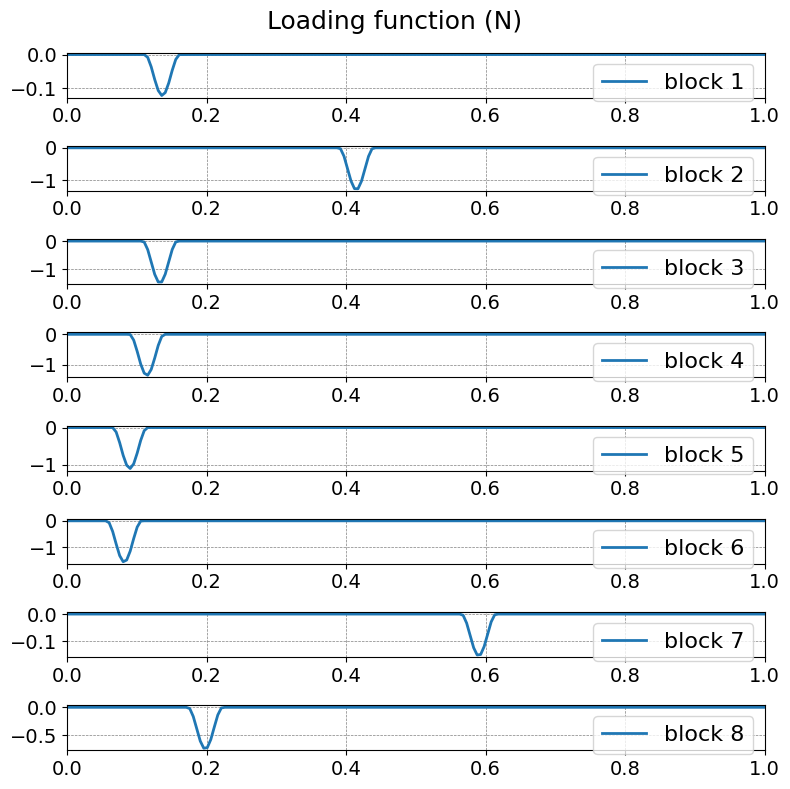

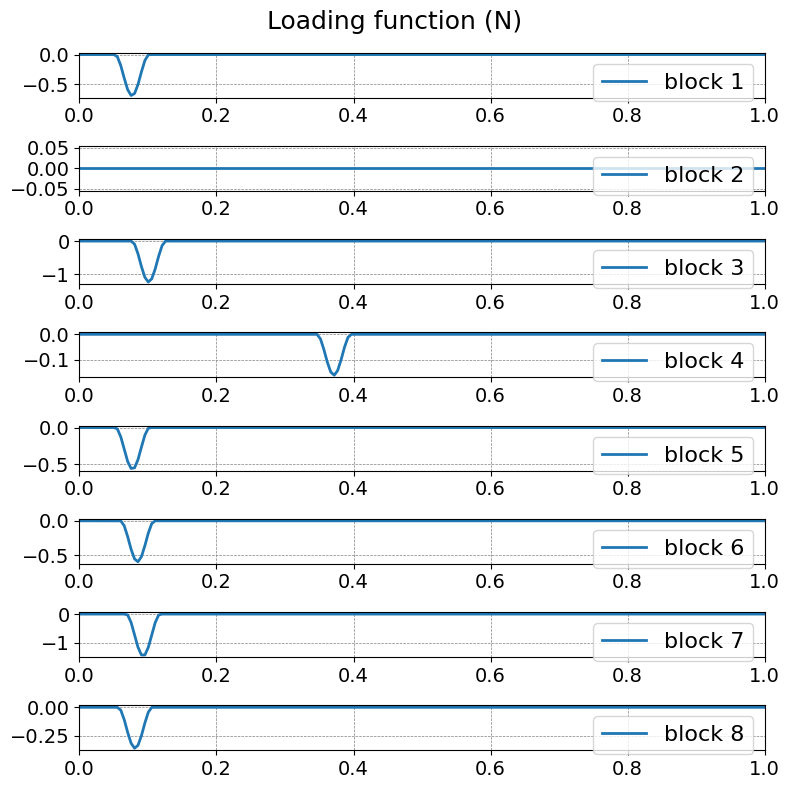

In [34]:
for count in range(2):
    output_data_temp = output_data[count]
    plt.figure(figsize=(8,8))
    for i in range(n_excited_blocks):
        plt.subplot(n_excited_blocks,1,i+1)
        plt.plot(ts, output_data_temp[:,i], label=f"block {i+1}")
        # plt.ylim(-max_value, 0.0)
        # plt.ylabel("Loading (N)")
        plt.legend()
    plt.suptitle("Loading function (N)")
    plt.tight_layout()
    plt.show()

In [8]:
from blockymetamaterials.plotting_input import generate_animation, compute_xy_limits

with open(f"01302026_simulation_results_n_source_16_measure_idx_48_exp_param_set_4_lr_0.1.pickle", "rb") as f:
    results_dict_opt = pickle.load(f)

with open(f"012326_circular_structure_dataset_n_source_8_exp_param_free_set_4.pickle", "rb") as f:
    results_dict = pickle.load(f)

num = 1 # data number
x_max = jnp.max( jnp.concatenate( [results_dict_opt["input_data"][num,:,0,:,0], results_dict["input_data"][num,:,0,:,0]], axis=0 ) )
x_min = jnp.min( jnp.concatenate( [results_dict_opt["input_data"][num,:,0,:,0], results_dict["input_data"][num,:,0,:,0]], axis=0 ) )
y_max = jnp.max( jnp.concatenate( [results_dict_opt["input_data"][num,:,0,:,1], results_dict["input_data"][num,:,0,:,1]], axis=0 ) )
y_min = jnp.min( jnp.concatenate( [results_dict_opt["input_data"][num,:,0,:,1], results_dict["input_data"][num,:,0,:,1]], axis=0 ) )

# x_lim = jnp.array([xlim_structure[0] + x_min, xlim_structure[1] + x_max])
# y_lim = jnp.array([ylim_structure[0] + y_min, ylim_structure[1] + y_max])

horizontal_shifts_opt = results_dict_opt["horizontal_shifts"]
vertical_shifts_opt = results_dict_opt["vertical_shifts"]

# horizontal_shifts, vertical_shifts = QuadGeometry_Circle_InputSource(n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_piece=n_piece).get_design_from_rotated_square(
#     angle=initial_angle,
# )  # Initial design

block_centroids_opt = block_centroids(horizontal_shifts_opt, vertical_shifts_opt)
centroid_node_vectors_opt = centroid_node_vectors(horizontal_shifts_opt, vertical_shifts_opt)

block_centroids_temp = block_centroids(horizontal_shifts, vertical_shifts)
centroid_node_vectors_temp = centroid_node_vectors(horizontal_shifts, vertical_shifts)

# step_set = jnp.arange(10)
step_set = jnp.arange(0,200,5)
# # step_set = [0]
# colors_list = ["b" for _ in range(geometry.n_blocks)]
# colors_list_opt = ["r" for _ in range(geometry.n_blocks)]
# colors_list[48] = "g"
# colors_list_opt[48] = "g"   

import matplotlib.cm as cm

# Compute velocity magnitudes
vel_mag_opt = (results_dict_opt["input_data"][num,:,1,:,0]**2 + results_dict_opt["input_data"][num,:,1,:,1]**2)**0.5
vel_mag = (results_dict["input_data"][num,:,1,:,0]**2 + results_dict["input_data"][num,:,1,:,1]**2)**0.5

# Flatten to compute global min/max for normalization across both
all_vels = jnp.concatenate([vel_mag.flatten(), vel_mag_opt.flatten()])
vmin = float(all_vels.min())
vmax = float(all_vels.max())

# Normalize and map to inferno colormap
norm_vel_mag_opt = (vel_mag_opt - vmin) / (vmax - vmin + 1e-12)
norm_vel_mag = (vel_mag - vmin) / (vmax - vmin + 1e-12)

# The shape is (steps, n_blocks), so convert each step's colors to RGBA
# cmap = cm.get_cmap('inferno')
# colormap_vel_opt = [cmap(norm_vel_mag_opt[step]) for step in range(norm_vel_mag_opt.shape[0])]
# colormap_vel = [cmap(norm_vel_mag[step]) for step in range(norm_vel_mag.shape[0])]
# # fig, ax = plt.subplots(figsize=(16,16))
# for step in step_set:
#     fig, ax = plt.subplots(figsize=(16,16))
#     plot_geometry(block_centroids_opt,
#                 centroid_node_vectors_opt,
#                 _bond_connectivity,
#                 block_displacements=results_dict_opt["input_data"][num,step,0,:,:],
#                 deformed=True, xlim=x_lim, ylim=y_lim,
#                 color=colormap_vel_opt[step], ax=ax)
#     # ax.axis("equal")
#     # ax.axis("off")
#     plt.savefig(f"Figure/Circular_structure/circular_structure_design_opt_design_data_num_{num}_step_{step}.eps")
#     plt.savefig(f"Figure/Circular_structure/circular_structure_design_opt_design_data_num_{num}_step_{step}.png")
#     plt.show()


# for step in step_set:
#     fig, ax = plt.subplots(figsize=(16,16))
#     plot_geometry(block_centroids_temp,
#                 centroid_node_vectors_temp,
#                 _bond_connectivity,
#                 block_displacements=results_dict["input_data"][num,step,0,:,:],
#                 deformed=True, xlim=x_lim, ylim=y_lim,
#                 color=colormap_vel[step], ax=ax)
#     ax.axis("equal")
#     ax.axis("off")
#     plt.savefig(f"Figure/Circular_structure/circular_structure_design_init_design_data_num_{num}_step_{step}.eps")
#     plt.savefig(f"Figure/Circular_structure/circular_structure_design_init_design_data_num_{num}_step_{step}.png")
#     plt.show()



input data shape :  (300, 200, 3, 105, 3)
TEST
peak_time : 0.08, idx=16, peak_value : 0.39
peak_time : 0.09, idx=18, peak_value : 1.53
peak_time : 0.29, idx=57, peak_value : 1.24
peak_time : 0.09, idx=18, peak_value : 1.43
peak_time : 0.08, idx=15, peak_value : 0.17
peak_time : 0.08, idx=16, peak_value : 0.36
peak_time : 0.18, idx=35, peak_value : 1.53
peak_time : 0.08, idx=16, peak_value : 0.59


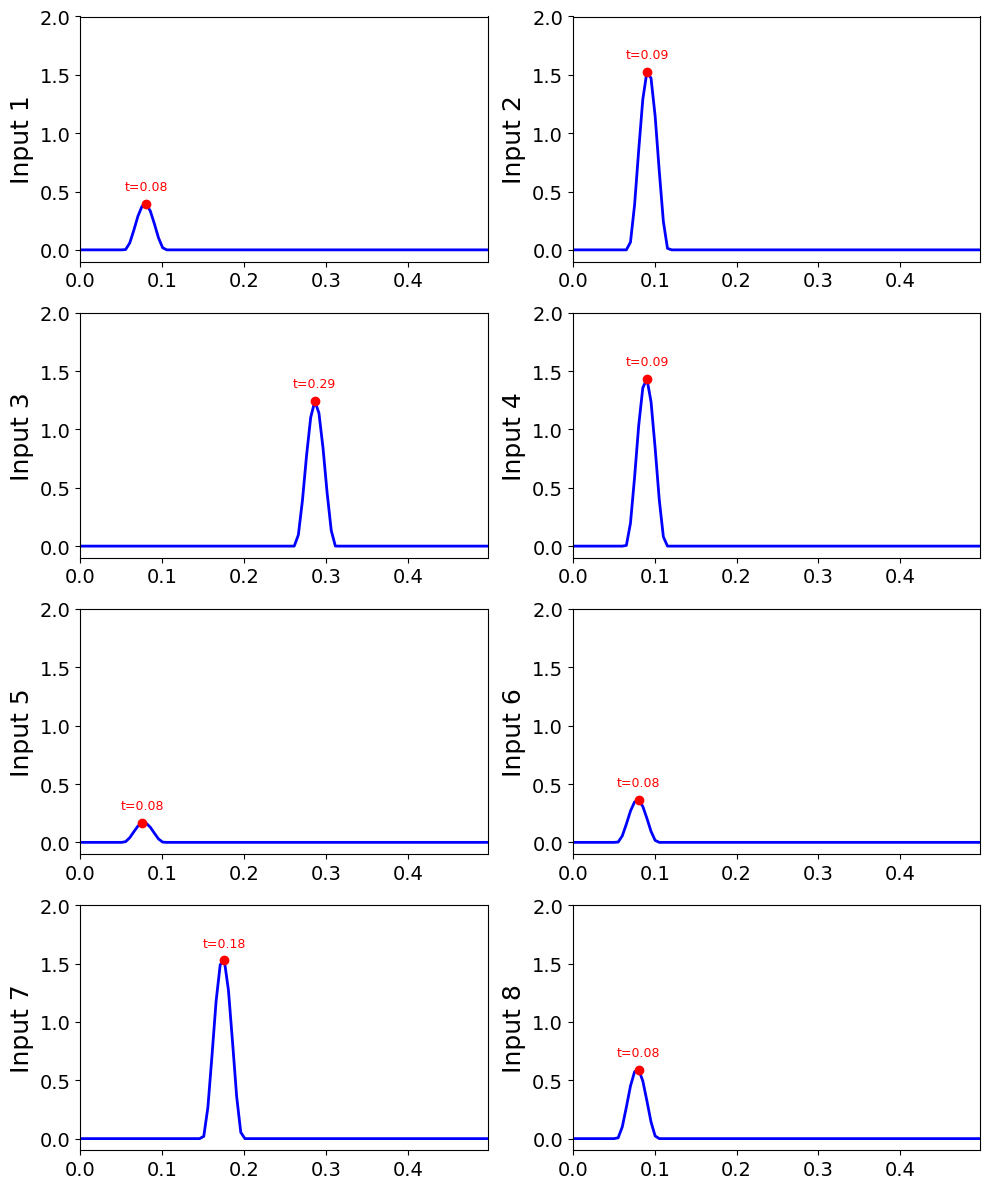

---------------------------------


In [33]:
with open(f"012326_circular_structure_dataset_n_source_8_exp_param_free_set_4.pickle", "rb") as f:
    data_dict = pickle.load(f)


measure_idx = 48
print("input data shape : ", data_dict["input_data"].shape)
input_data = jnp.zeros_like(data_dict["input_data"][:,:,2,measure_idx,:].squeeze()) # (N, time_steps, 3)
input_data = input_data.at[:,:,0:2].set(data_dict["input_data"][:,:,2,measure_idx,0:2].squeeze()) # (N, time_steps, 2)
input_data = input_data.at[:,:,2].set(data_dict["input_data"][:,:,1,measure_idx,2].squeeze()) # (N, time_steps, 2)
output_data = data_dict["output_data"]

key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

N = 100
print("TEST")
for i in range(26, 27):
    plt.figure(figsize=(10, 1.5 * n_piece))
    for j in range(n_piece):
        plt.subplot(n_piece // 2, 2, 1 + j)
        plt.plot(ts[:N], -test_output_data[i, :N, j], "b-", label="True")
        # Find the index of the peak (maximum value)
        peak_idx = jnp.argmax(-test_output_data[i, :N, j])
        peak_time = ts[peak_idx]
        peak_value = -test_output_data[i, peak_idx, j]
        # Mark the peak on the plot
        plt.plot([peak_time], [peak_value], "ro")
        print(f"peak_time : {peak_time:.2f}, idx={peak_idx}, peak_value : {peak_value:.2f}")
        plt.annotate(
            f"t={peak_time:.2f}",
            (peak_time, peak_value),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            color="red",
            fontsize=9,
        )
        plt.ylim(-0.1,2.0)
        plt.ylabel(f"Input {j+1}")
    plt.tight_layout()
    # plt.suptitle(f"Test {i}")
    plt.savefig(f"Figure/111925_sim_prediction_test_{i}_force_data.eps")
    plt.show()
    print("---------------------------------")

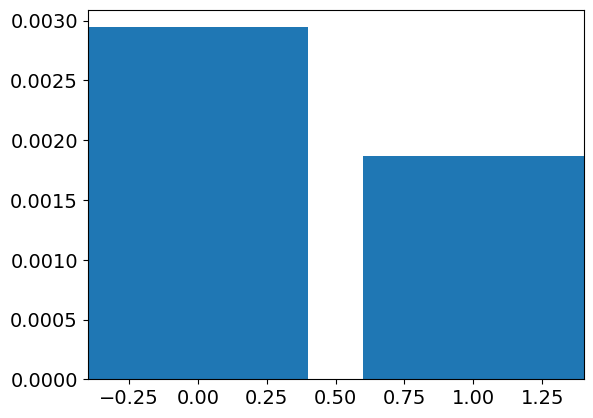

In [52]:
loss = [2.9445e-3, 1.8711e-3]

plt.bar(range(len(loss)), loss)
# plt.ylim(1e-4, 2e-3)
# plt.yscale("log")
plt.savefig(f"Figure/Circular_structure/init_opt_compare_loss.eps")
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


16
18
57
18
15
16
35
16
20
20
57
20
20
20
35
20


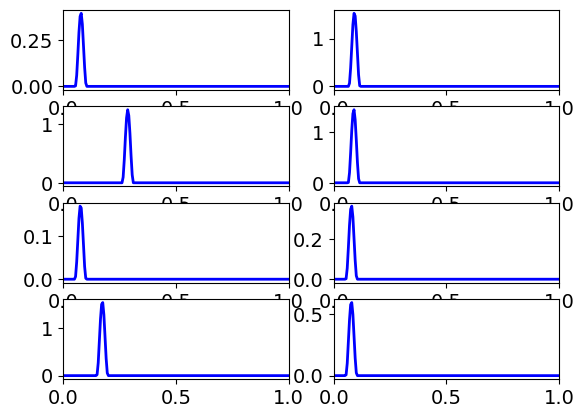

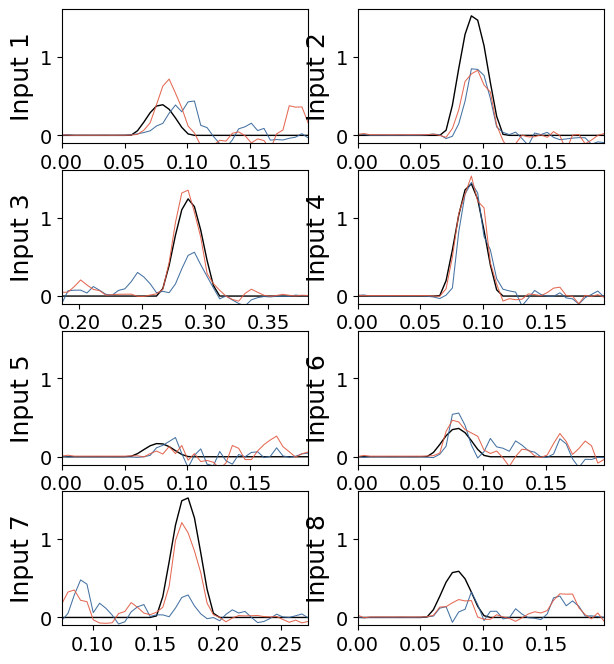

In [40]:
step_set = []
num = 26
N = 20
for j in range(n_piece):
    plt.subplot(n_piece // 2, 2, 1 + j)
    plt.plot(ts, -test_output_data[num, :, j], "b-", label="True")
    # Find the index of the peak (maximum value)
    peak_idx = jnp.argmax(-test_output_data[num, :, j])
    print(peak_idx)
    step_set.append(peak_idx)

for i in range(num, num+1):
    # plt.figure(figsize=(7,1.*n_piece))
    fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
    axes = axes.flatten()
    for j in range(n_piece):
        ax = axes[j]
    
        peak_idx = step_set[j]
        if peak_idx - N < 0:
            peak_idx = N
        print(peak_idx)
        ax.plot( ts[peak_idx-N:peak_idx+N], -test_output_data[i,peak_idx-N:peak_idx+N,j],  "k-",linewidth=1.0,label="True")
        ax.plot( ts[peak_idx-N:peak_idx+N], -pred_y_org_test[i,peak_idx-N:peak_idx+N,j], color=color_list[0],  alpha=0.9, linewidth=0.75, label="Prediction from CNN")
        ax.plot( ts[peak_idx-N:peak_idx+N], -pred_y_org_test_opt[i,peak_idx-N:peak_idx+N,j], color=color_list[1], alpha=0.9, linewidth=0.75, label="Prediction from CNN (optimized)")
        ax.set_ylim(-0.1, -min_value)
        ax.set_ylabel(f"Input {j+1}")
        # ax.set_xticklabels([])
        # ax.set_yticklabels([])
    # plt.tight_layout()
    plt.savefig(f"Figure/Circular_structure/111925_sim_opt_init_prediction_test_data_{i}_cut_{N}_v3.eps")
    plt.savefig(f"Figure/Circular_structure/111925_sim_opt_init_prediction_test_data_{i}_cut_{N}_v3.png")
    plt.show()

In [ ]:
# prediction comparison


hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
with open(f"01302026_circular_structure_cooptimization_n_source_16_measure_idx_48_exp_param_set_4_lr_0.1.pickle", "rb") as f:
    record_dict = pickle.load(f)
param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

min_idx = jnp.argmin(jnp.array(loss_record))

# load simulation data
key = random.PRNGKey(0)
filename = f"012326_circular_structure_dataset_n_source_8_exp_param_free_set_4.pickle"

print("Checking for data file at:", filename)
with open(filename, "rb") as f:
    data_dict = pickle.load(f)

measure_idx = 48
print("input data shape : ", data_dict["input_data"].shape)
input_data = jnp.zeros_like(data_dict["input_data"][:,:,2,measure_idx,:].squeeze()) # (N, time_steps, 3)
input_data = input_data.at[:,:,0:2].set(data_dict["input_data"][:,:,2,measure_idx,0:2].squeeze()) # (N, time_steps, 2)
input_data = input_data.at[:,:,2].set(data_dict["input_data"][:,:,1,measure_idx,2].squeeze()) # (N, time_steps, 2)
output_data = data_dict["output_data"]

# angle_cut = 360. / geometry.n_piece
# def map_func(output_data_single):
#     output_data_temp = jnp.zeros( (n_timepoints, 2*n_excited_blocks) ) # (ts, boundary blocks * 2)
#     for i in range(n_excited_blocks):
#         normal_angle = (+180 - angle_cut/2. - angle_cut * i) * jnp.pi / 180.
#         output_data_temp = output_data_temp.at[:,i].set( output_data_single[:,i] * jnp.cos(normal_angle) )
#         output_data_temp = output_data_temp.at[:,n_excited_blocks+i].set( output_data_single[:,i] * jnp.sin(normal_angle) )
#     return output_data_temp
# output_data_all = vmap(map_func)(output_data)

test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

print("data size : ", input_data.shape)
print("data size : ", output_data.shape)

mm_scaler = minmax_scaler(training_input_data, training_output_data)
mm_scaler.information()

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

model = TimeSeriesCNN(output_features=n_piece)
init_params = model.init(key, input_data)
preds = model.apply(init_params, input_data)

params_init = in_param_record[0][0]
pred_y = model.apply(params_init, train_data_normalized)
pred_y_test = model.apply(params_init, test_data_normalized)

_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)


# print("TRAIN")
# for i in range(10,20):
#     plt.figure(figsize=(10,1.5*n_source))
#     for j in range(n_source):
#         plt.subplot(n_source//2,2,1+j)
#         plt.plot( ts, training_output_data[i,:,j], "b-",label="True")
#         plt.plot( ts, pred_y_org[i,:,j], "r-",label="Prediction from CNN")
#         plt.ylim(-1.,0.1)
#         # plt.ylabel(f"Input {j+1}")
#     plt.tight_layout()
#     # plt.suptitle(f"Train {i}")
#     plt.savefig(f"Figure/111925_sim_prediction_train_data_{i}.eps")
#     plt.show()

# print("TEST")
# for i in range(10,20):
#     plt.figure(figsize=(10,1.5*n_source))
#     for j in range(n_source):
#         plt.subplot(n_source//2,2,1+j)
#         plt.plot( ts, test_output_data[i,:,j], "b-",label="True")
#         plt.plot( ts, pred_y_org_test[i,:,j], "r-", label="Prediction from CNN")
#         plt.ylim(-1.,0.1)
#         # plt.ylabel(f"Input {j+1}")
#     plt.tight_layout()
#     # plt.suptitle(f"Test {i}")
#     plt.savefig(f"Figure/111925_sim_prediction_test_data_{i}.eps")
#     plt.show()

params_opt = in_param_record[min_idx][0]
training_input_data = in_param_record[min_idx][2]
training_output_data = in_param_record[min_idx][3]
test_input_data = in_param_record[min_idx][4]
test_output_data = in_param_record[min_idx][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
print( jnp.max(train_output_normalized), jnp.min(train_output_normalized) )

pred_y = model.apply(params_opt, train_data_normalized)
pred_y_test = model.apply(params_opt, test_data_normalized)

_, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)
# _, training_output_data = mm_scaler.inverse_transform(train_data_normalized, train_output_normalized)
# _, test_output_data = mm_scaler.inverse_transform(test_data_normalized, test_output_normalized)

# print( jnp.max(pred_y_org), jnp.min(pred_y_org) )

mse = jnp.mean((pred_y_org_opt - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test - test_output_data)**2)
print(f"training loss in original scale : {mse:.4e}")
print(f"test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(jnp.concatenate([training_output_data, test_output_data]))
color_list = ["#316398", "#e15941"]
# print("TRAIN")
# for i in range(20,30):
#     plt.figure(figsize=(10,1.5*n_source))
#     for j in range(n_source):
#         plt.subplot(n_source//2,2,1+j)
#         plt.plot( ts, training_output_data[i,:,j], "k-", label="True")
#         plt.plot( ts, pred_y_org[i,:,j], color=color_list[0], label="Prediction from CNN")
#         plt.plot( ts, pred_y_org_opt[i,:,j], color=color_list[1], label="Prediction from CNN (optimized)")
#         plt.ylim(min_value,0.1)
#         # plt.ylabel(f"Input {j+1}")
#     plt.tight_layout()
#     plt.suptitle(f"Train {i}")
#     plt.savefig(f"Figure/111925_sim_init_opt_prediction_train_data_{i}.eps")
#     plt.show()

N = 100
print("TEST")
for i in range(20,30):
    fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
    axes = axes.flatten()
    for j in range(n_piece):
        ax = axes[j]
        ax.plot( ts[:N], -test_output_data[i,:N,j],  "k-",linewidth=1.0,label="True")
        ax.plot( ts[:N], -pred_y_org_test[i,:N,j], color=color_list[0],  alpha=0.9, linewidth=0.75, label="Prediction from CNN")
        ax.plot( ts[:N], -pred_y_org_test_opt[i,:N,j], color=color_list[1], alpha=0.9, linewidth=0.75, label="Prediction from CNN (optimized)")
        ax.set_ylim(-0.1, -min_value)
        plt.ylabel(f"Input {j+1}")
    plt.suptitle(f"Test {i}")
    plt.tight_layout()
    plt.savefig(f"Figure/Circular_structure/111925_sim_init_opt_prediction_test_data_{i}_cut_{N}.eps")
    plt.savefig(f"Figure/Circular_structure/111925_sim_init_opt_prediction_test_data_{i}_cut_{N}.png")
    plt.show()


# N = 100
# print("TEST")
for i in range(20,30):
    # plt.figure(figsize=(7,1.*n_piece))
    fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
    axes = axes.flatten()
    for j in range(n_piece):
        ax = axes[j]
        ax.plot( ts[:N], -test_output_data[i,:N,j],  "k-",linewidth=1.0,label="True")
        ax.plot( ts[:N], -pred_y_org_test[i,:N,j], color=color_list[0],  alpha=0.9, linewidth=0.75, label="Prediction from CNN")
        ax.plot( ts[:N], -pred_y_org_test_opt[i,:N,j], color=color_list[1], alpha=0.9, linewidth=0.75, label="Prediction from CNN (optimized)")
        ax.set_ylim(-0.1, -min_value)
        ax.set_ylabel(f"Input {j+1}")
        ax.set_xticklabels([])
        ax.set_yticklabels([])
    # plt.tight_layout()
    plt.savefig(f"Figure/Circular_structure/111925_sim_opt_init_prediction_test_data_{i}_cut_{N}_v2.eps")
    plt.savefig(f"Figure/Circular_structure/111925_sim_opt_init_prediction_test_data_{i}_cut_{N}_v2.png")
    plt.show()


# diff_init = jnp.abs(-test_output_data + pred_y_org_test)
# diff_opt = jnp.abs(-test_output_data + pred_y_org_test_opt)
# max_value = jnp.max(jnp.abs(jnp.concatenate([diff_init, diff_opt], axis=0)))
# N = -1
# print("TEST")
# fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
# axes = axes.flatten()
# for i in range(len(test_output_data)):
#     for j in range(n_piece):
#         ax = axes[j]
#         ax.plot( ts[:N], diff_init[i,:N,j], color=color_list[0], alpha=0.7, linewidth=0.75, label="Prediction from CNN")
#         # plt.plot( ts[:N], diff_opt[i,:N,j], color=color_list[1], linestyle=':', linewidth=0.75, label="Prediction from CNN (optimized)")
#         ax.set_ylim(-1e-2, max_value)
#         ax.set_ylabel(f"Input {j+1}")
#         # ax.set_xticks([])
#         # ax.set_yticks([])
#         ax.set_xticklabels([])
#         ax.set_yticklabels([])
# plt.savefig(f"Figure/Circular_structure/111925_sim_diff_init_prediction_test_data_{i}_cut_{N}.eps")
# # plt.savefig(f"Figure/Circular_structure/111925_sim_diff_init_prediction_test_data_{i}_cut_{N}.png")
# plt.show()

# fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
# axes = axes.flatten()
# for i in range(len(test_output_data)):
#     for j in range(n_piece):
#         ax = axes[j]
#         # plt.subplot(n_piece//2,2,1+j)
#         ax.plot( ts[:N], diff_init[i,:N,j], color=color_list[0], alpha=0.7, linewidth=0.75, label="Prediction from CNN")
#         ax.plot( ts[:N], diff_opt[i,:N,j], color=color_list[1], alpha=0.7,linewidth=0.75, label="Prediction from CNN (optimized)")
#         ax.set_ylim(-1e-2, max_value)
#         ax.set_ylabel(f"Input {j+1}")
#         # ax.set_xticks([])
#         # ax.set_yticks([])
#         ax.set_xticklabels([])
#         ax.set_yticklabels([])
# # plt.tight_layout()
# plt.savefig(f"Figure/Circular_structure/111925_sim_diff_all_prediction_test_data_{i}_cut_{N}.eps")
# # plt.savefig(f"Figure/Circular_structure/111925_sim_diff_opt_prediction_test_data_{i}_cut_{N}.png")
# plt.show()

initial loss : 1.6429e-03
minimum loss : 9.1280e-04


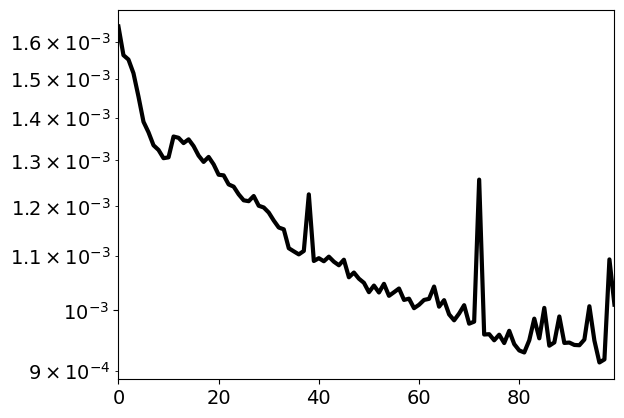

In [ ]:

with open(f"02262026_circular_structure_cooptimization_n_source_16_measure_idx_28_68_exp_param_set_4_lr_0.1.pickle", "rb") as f:
    record_dict = pickle.load(f)

param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")

plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), '-', lw=3, color=color_list[0])
# plt.title('Cooptimization : design training curve')
plt.yscale('log')
# plt.ylabel("Outer loss")
# plt.xlabel("Iterations")
# plt.savefig(f"Figure/circular_structure_loss_curve.eps")
# plt.legend()
plt.show()


96


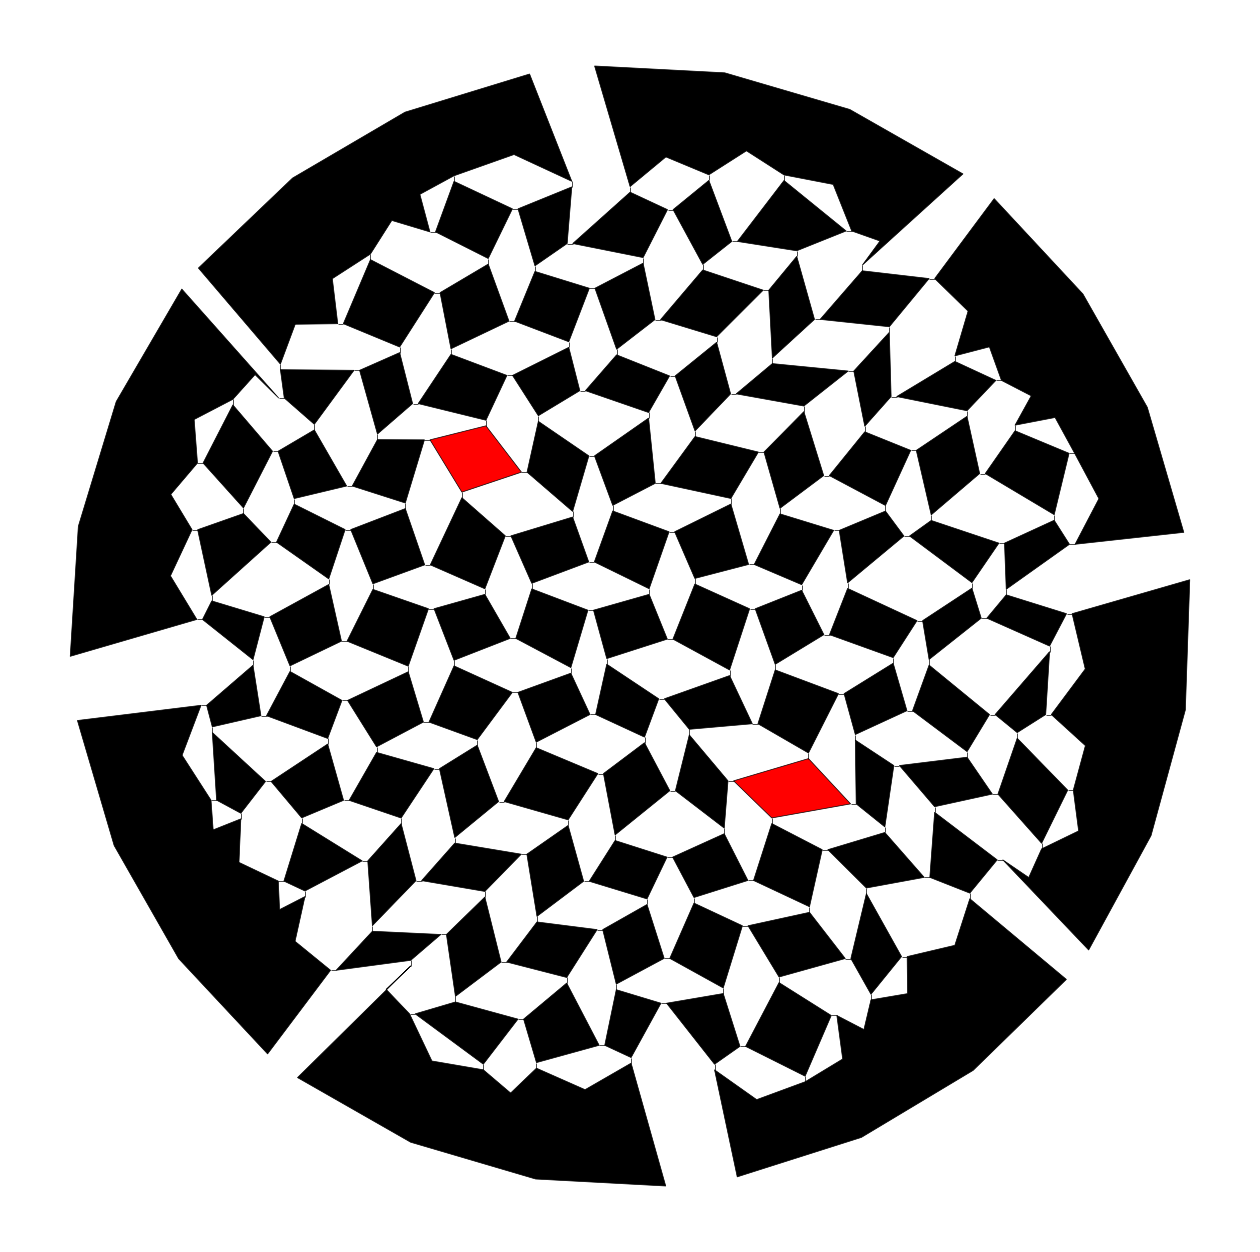

In [19]:
from blockymetamaterials.plotting_input import plot_geometry, compute_xy_limits

opt_idx = jnp.argmin(jnp.array(loss_record))
print(opt_idx)
meta_params = param_record[opt_idx]
hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))

design_values = (horizontal_shifts, vertical_shifts)
block_centroids_temp = block_centroids(horizontal_shifts, vertical_shifts)
centroid_node_vectors_temp = centroid_node_vectors(horizontal_shifts, vertical_shifts)

shell_verts = jnp.concatenate([ centroids + vertices for centroids, vertices in zip(centroid_node_vectors_temp, centroid_node_vectors_temp)], axis=0)
# from blockymetamaterials.plotting import generate_animation
# solution = input_data
xlim, ylim = compute_xy_limits(
    shell_verts) + 0.5*geometry.spacing * jnp.array([-1, 1])

fig, ax = plt.subplots(figsize=(16,16))
block_idx = jnp.concatenate( (geometry.blocks_inside, jnp.arange(geometry.n_quads, geometry.n_quads+geometry.n_piece)), dtype=int  )
# colors = 'k'
colors = ['k' for i in range(geometry.n_quads+geometry.n_piece)]
measure_idx = [28, 68]
for i in measure_idx:
    colors[i] = 'r'

plot_geometry(block_centroids_temp,
              centroid_node_vectors_temp,
              _bond_connectivity,
              color=colors, ax=ax)
ax.axis("equal")
ax.axis("off")
# plt.savefig(f"Figure/122525_circular_structure_design_n1_blocks_{n1_blocks}_n2_blocks_{n2_blocks}_measure_idx_28_68_n_source_{n_source}_opt_design.eps")
plt.show()

In [32]:

with open(f"02262026_circular_structure_cooptimization_n_source_16_measure_idx_28_68_exp_param_set_4_lr_0.1.pickle", "rb") as f:
    record_dict = pickle.load(f)

param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

filename = f"012326_circular_structure_dataset_n_source_8_exp_param_free_set_4_idx_28_68.pickle"
with open(filename, "rb") as f:
    data_dict = pickle.load(f)
input_data = data_dict["input_data"]
output_data = data_dict["output_data"]

min_idx = jnp.argmin(jnp.array(loss_record))
key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

mm_scaler = minmax_scaler(training_input_data, training_output_data)
mm_scaler.information()

params_init = in_param_record[0][0]
training_input_data = in_param_record[0][2]
training_output_data = in_param_record[0][3]
test_input_data = in_param_record[0][4]
test_output_data = in_param_record[0][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

model = TimeSeriesCNN(output_features=n_piece)
init_params = model.init(key, input_data)
preds = model.apply(init_params, input_data)

pred_y = model.apply(params_init, train_data_normalized)
pred_y_test = model.apply(params_init, test_data_normalized)

_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

mse = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Initial training loss : {mse:.4e}")
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Initial test loss : {mse_test:.4e}")

mse = jnp.mean((pred_y_org - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test - test_output_data)**2)
print(f"Initial training loss in original scale : {mse:.4e}")
print(f"Initial test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(output_data)
# for i in range(2):
#     # plt.figure(figsize=(7,1.*n_piece))
#     fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
#     axes = axes.flatten()
#     for j in range(n_piece):
#         ax = axes[j]
#         ax.plot( ts, -test_output_data[i,:,j],  "k-",linewidth=1.0,label="True")
#         ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[0],  alpha=0.9, linewidth=0.75, label="Prediction from CNN")
#         # ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[1], alpha=0.9, linewidth=0.75, label="Prediction from CNN (optimized)")
#         ax.set_ylim(-0.1, -min_value)
#         ax.set_ylabel(f"Input {j+1}")
#         # ax.set_xticklabels([])
#         # ax.set_yticklabels([])
#     # plt.tight_layout()
#     # plt.savefig(f"Figure/Circular_structure/2_sensors_sim_opt_init_prediction_test_data_{i}.eps")
#     # plt.savefig(f"Figure/Circular_structure/2_sensors_sim_opt_init_prediction_test_data_{i}.png")
#     plt.show()

print("--------------------------------")
params_opt = in_param_record[min_idx][0]
training_input_data = in_param_record[min_idx][2]
training_output_data = in_param_record[min_idx][3]
test_input_data = in_param_record[min_idx][4]
test_output_data = in_param_record[min_idx][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
print( jnp.max(train_output_normalized), jnp.min(train_output_normalized) )

pred_y = model.apply(params_opt, train_data_normalized)
pred_y_test = model.apply(params_opt, test_data_normalized)

_, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)


mse = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Optimized training loss : {mse:.4e}")
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Optimized test loss : {mse_test:.4e}")

mse = jnp.mean((pred_y_org_opt - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test_opt - test_output_data)**2)
print(f"Optimized training loss in original scale : {mse:.4e}")
print(f"Optimized test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(jnp.concatenate([training_output_data, test_output_data]))
# color_list = ["#cc3f40", "#bdccd4", "#0b2456",]
color_list = ["k", "b", "r",]

# N = 100
# print("TEST")
# for i in range(30):
#     fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
#     axes = axes.flatten()
#     for j in range(n_piece):
#         ax = axes[j]
#         ax.plot( ts, -test_output_data[i,:,j],  color=color_list[0],linewidth=1.0,label="True")
#         ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1],  alpha=0.9, linewidth=0.75, label="Prediction from CNN")
#         ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], alpha=0.9, linewidth=0.75, label="Prediction from CNN (optimized)")
#         ax.set_ylim(-0.1, -min_value)
#         # plt.ylabel(f"Input {j+1}")
#     init_loss = jnp.mean((pred_y_org_test[i] - test_output_data[i])**2)
#     opt_loss = jnp.mean((pred_y_org_test_opt[i] - test_output_data[i])**2)
#     plt.suptitle(f"Test {i} Init loss : {init_loss:.4e}, Opt loss : {opt_loss:.4e}")
#     plt.tight_layout()
#     # plt.savefig(f"Figure/Circular_structure/2_sensors_sim_init_opt_prediction_test_data_{i}.eps")
#     plt.savefig(f"Figure/Circular_structure/2_sensors_sim_init_opt_prediction_test_data_{i}.png")
#     plt.show()


(1, 1, 6) (1, 1, 6)
(1, 1, 8) (1, 1, 8)
data min :  [[[-5.38646437e+03 -6.73516303e+03 -3.08640715e+00 -5.65600645e+03
   -6.80367286e+03 -2.55886262e+00]]]
data max :  [[[6.10869538e+03 4.54609144e+03 2.88751215e+00 4.85260663e+03
   6.06358385e+03 2.41735054e+00]]]
test data min :  [[[-1.6038084  -1.58341525 -1.60596609 -1.61064834 -1.60504719
   -1.59252717 -1.60786702 -1.58384888]]]
test data max :  [[[-0. -0. -0. -0. -0. -0. -0. -0.]]]
Initial training loss : 1.7528e-03
Initial test loss : 1.6429e-03
Initial training loss in original scale : 4.4819e-03
Initial test loss in original scale : 4.2088e-03
--------------------------------
1.0 0.0
Optimized training loss : 1.2009e-03
Optimized test loss : 9.1280e-04
Optimized training loss in original scale : 3.0677e-03
Optimized test loss in original scale : 2.3369e-03


initial loss : 9.1212e-04
minimum loss : 5.1660e-04


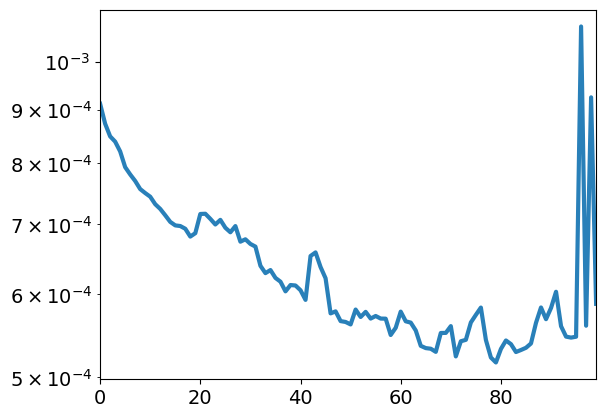

In [12]:

with open(f"02262026_circular_structure_cooptimization_n_source_16_measure_idx_24_28_70_exp_param_set_4_lr_0.1.pickle", "rb") as f:
    record_dict = pickle.load(f)

param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")

plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), '-', lw=3, color=color_list[0])
# plt.title('Cooptimization : design training curve')
plt.yscale('log')
# plt.ylabel("Outer loss")
# plt.xlabel("Iterations")
# plt.savefig(f"Figure/circular_structure_loss_curve.eps")
# plt.legend()
plt.show()


In [37]:
def plot_circle_structure(meta_params, measure_idx, save_fig=False, filename=None):
    hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
    horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
    vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))

    design_values = (horizontal_shifts, vertical_shifts)
    block_centroids_temp = block_centroids(horizontal_shifts, vertical_shifts)
    centroid_node_vectors_temp = centroid_node_vectors(horizontal_shifts, vertical_shifts)

    shell_verts = jnp.concatenate([ centroids + vertices for centroids, vertices in zip(centroid_node_vectors_temp, centroid_node_vectors_temp)], axis=0)
    # from blockymetamaterials.plotting import generate_animation
    # solution = input_data
    xlim, ylim = compute_xy_limits(
        shell_verts) + 0.5*geometry.spacing * jnp.array([-1, 1])

    fig, ax = plt.subplots(figsize=(16,16))
    block_idx = jnp.concatenate( (geometry.blocks_inside, jnp.arange(geometry.n_quads, geometry.n_quads+geometry.n_piece)), dtype=int  )
    colors = ['k' for i in range(geometry.n_quads+geometry.n_piece)]
    # measure_idx = [24, 28, 70]
    for i in measure_idx:
        colors[i] = 'r'
    plot_geometry(block_centroids_temp,
                centroid_node_vectors_temp,
                _bond_connectivity,
                color=colors, ax=ax)
    ax.axis("equal")
    ax.axis("off")
    if save_fig:
        plt.savefig(filename)
    plt.show()

In [ ]:
from blockymetamaterials.plotting_input import plot_geometry, compute_xy_limits

meta_params = param_record[min_idx]
measure_idx = [24, 28, 70]
filename =f"Figure/122525_circular_structure_design_n1_blocks_{n1_blocks}_n2_blocks_{n2_blocks}_measure_idx_24_28_70_n_source_{n_source}_opt_design.eps"
plot_circle_structure(meta_params, measure_idx, save_fig=True, filename=filename)

initial loss : 2.9445e-03
minimum loss : 1.8711e-03
initial loss : 1.6429e-03
minimum loss : 9.1280e-04
initial loss : 9.1212e-04
minimum loss : 5.1660e-04


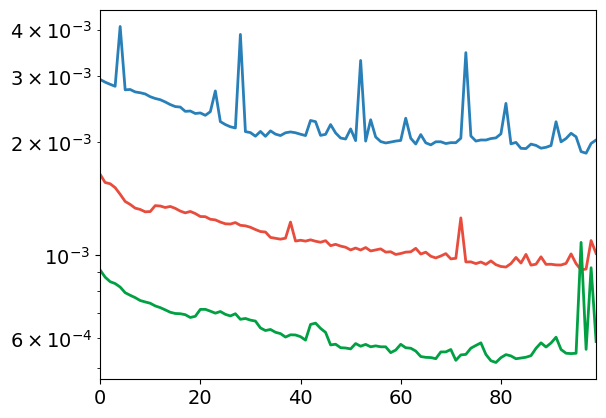

In [10]:
file_list = [f"01302026_circular_structure_cooptimization_n_source_16_measure_idx_48_exp_param_set_4_lr_0.1.pickle",
            f"02262026_circular_structure_cooptimization_n_source_16_measure_idx_28_68_exp_param_set_4_lr_0.1.pickle",
            f"02262026_circular_structure_cooptimization_n_source_16_measure_idx_24_28_70_exp_param_set_4_lr_0.1.pickle"]

for i in range(3):
    file_name = file_list[i]
    with open(file_name, "rb") as f:
        record_dict = pickle.load(f)

    param_record = record_dict["design_record"]
    in_param_record = record_dict["nn_record"]
    loss_record = record_dict["loss_record"]

    print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
    print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")

    plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), '-', color=color_list[i])
# plt.title('Cooptimization : design training curve')
plt.yscale('log')
# plt.ylabel("Outer loss")
# plt.xlabel("Iterations")
# plt.savefig(f"Figure/circular_structure_loss_curve.eps")
# plt.legend()
plt.show()

In [33]:

with open(f"02262026_circular_structure_cooptimization_n_source_16_measure_idx_24_28_70_exp_param_set_4_lr_0.1.pickle", "rb") as f:
    record_dict = pickle.load(f)

param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

filename = f"012326_circular_structure_dataset_n_source_8_exp_param_free_set_4_idx_24_28_70.pickle"
with open(filename, "rb") as f:
    data_dict = pickle.load(f)
input_data = data_dict["input_data"]
output_data = data_dict["output_data"]

min_idx = jnp.argmin(jnp.array(loss_record))
key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

mm_scaler = minmax_scaler(training_input_data, training_output_data)
mm_scaler.information()

params_init = in_param_record[0][0]
training_input_data = in_param_record[0][2]
training_output_data = in_param_record[0][3]
test_input_data = in_param_record[0][4]
test_output_data = in_param_record[0][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

model = TimeSeriesCNN(output_features=n_piece)
init_params = model.init(key, input_data)
preds = model.apply(init_params, input_data)

pred_y = model.apply(params_init, train_data_normalized)
pred_y_test = model.apply(params_init, test_data_normalized)

_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

mse = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Initial training loss : {mse:.4e}")
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Initial test loss : {mse_test:.4e}")

mse = jnp.mean((pred_y_org - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test - test_output_data)**2)
print(f"Initial training loss in original scale : {mse:.4e}")
print(f"Initial test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(output_data)
# for i in range(2):
#     # plt.figure(figsize=(7,1.*n_piece))
#     fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
#     axes = axes.flatten()
#     for j in range(n_piece):
#         ax = axes[j]
#         ax.plot( ts, -test_output_data[i,:,j],  "k-",linewidth=1.0,label="True")
#         ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[0],  alpha=0.9, linewidth=0.75, label="Prediction from CNN")
#         # ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[1], alpha=0.9, linewidth=0.75, label="Prediction from CNN (optimized)")
#         ax.set_ylim(-0.1, -min_value)
#         ax.set_ylabel(f"Input {j+1}")
#         # ax.set_xticklabels([])
#         # ax.set_yticklabels([])
#     # plt.tight_layout()
#     # plt.savefig(f"Figure/Circular_structure/2_sensors_sim_opt_init_prediction_test_data_{i}.eps")
#     # plt.savefig(f"Figure/Circular_structure/2_sensors_sim_opt_init_prediction_test_data_{i}.png")
#     plt.show()

print("--------------------------------")
params_opt = in_param_record[min_idx][0]
training_input_data = in_param_record[min_idx][2]
training_output_data = in_param_record[min_idx][3]
test_input_data = in_param_record[min_idx][4]
test_output_data = in_param_record[min_idx][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
print( jnp.max(train_output_normalized), jnp.min(train_output_normalized) )

pred_y = model.apply(params_opt, train_data_normalized)
pred_y_test = model.apply(params_opt, test_data_normalized)

_, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)


mse = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Optimized training loss : {mse:.4e}")
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Optimized test loss : {mse_test:.4e}")

mse = jnp.mean((pred_y_org_opt - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test_opt - test_output_data)**2)
print(f"Optimized training loss in original scale : {mse:.4e}")
print(f"Optimized test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(jnp.concatenate([training_output_data, test_output_data]))
# color_list = ["#cc3f40", "#bdccd4", "#0b2456",]
color_list = ["k", "b", "r",]

# N = 100
# print("TEST")
# for i in range(30):
#     fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
#     axes = axes.flatten()
#     for j in range(n_piece):
#         ax = axes[j]
#         ax.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=1.0, label="True")
#         ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], alpha=0.9, linewidth=1.0, label="Prediction from CNN")
#         ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], alpha=0.9, linewidth=1.0, label="Prediction from CNN (optimized)")
#         # ax.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=1.0, label="True")
#         # ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], alpha=0.9, linewidth=0.75, label="Prediction from CNN")
#         # ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], alpha=0.9, linewidth=0.75, label="Prediction from CNN (optimized)")
#         ax.set_ylim(-0.1, -min_value)
#         # plt.ylabel(f"Input {j+1}")
#     init_loss = jnp.mean((pred_y_org_test[i] - test_output_data[i])**2)
#     opt_loss = jnp.mean((pred_y_org_test_opt[i] - test_output_data[i])**2)
#     plt.suptitle(f"Test {i} Init loss : {init_loss:.4e}, Opt loss : {opt_loss:.4e}")
#     plt.tight_layout()
#     # plt.savefig(f"Figure/Circular_structure/3_sensors_sim_init_opt_prediction_test_data_{i}.eps")
#     plt.savefig(f"Figure/Circular_structure/3_sensors_sim_init_opt_prediction_test_data_{i}.png")
#     plt.show()


(1, 1, 9) (1, 1, 9)
(1, 1, 8) (1, 1, 8)
data min :  [[[-5.83967626e+03 -5.81301684e+03 -2.51068774e+00 -5.36595116e+03
   -6.73705333e+03 -3.08796559e+00 -5.10431507e+03 -6.08216801e+03
   -2.64080925e+00]]]
data max :  [[[4.32015954e+03 5.06374682e+03 3.07899269e+00 6.10222431e+03
   4.56093013e+03 2.87925026e+00 5.00641119e+03 5.77678358e+03
   2.23269826e+00]]]
test data min :  [[[-1.6038084  -1.58341525 -1.60596609 -1.61064834 -1.60504719
   -1.59252717 -1.60786702 -1.58384888]]]
test data max :  [[[-0. -0. -0. -0. -0. -0. -0. -0.]]]
Initial training loss : 9.9474e-04
Initial test loss : 9.1212e-04
Initial training loss in original scale : 2.5429e-03
Initial test loss in original scale : 2.3348e-03
--------------------------------
1.0 0.0
Optimized training loss : 6.2814e-04
Optimized test loss : 5.1660e-04
Optimized training loss in original scale : 1.6042e-03
Optimized test loss in original scale : 1.3221e-03


initial loss : 2.9445e-03
minimum loss : 1.8711e-03


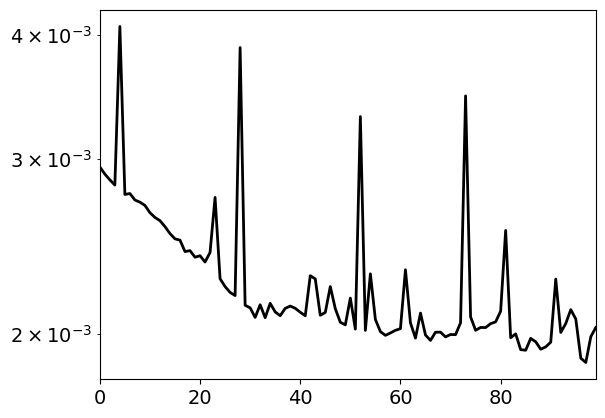

(1, 1, 3) (1, 1, 3)
(1, 1, 8) (1, 1, 8)
data min :  [[[-6.69843446e+03 -5.65925001e+03 -2.26316094e+00]]]
data max :  [[[6.44550367e+03 5.19665138e+03 2.12235312e+00]]]
test data min :  [[[-1.6038084  -1.58341525 -1.60596609 -1.61064834 -1.60504719
   -1.59252717 -1.60786702 -1.58384888]]]
test data max :  [[[-0. -0. -0. -0. -0. -0. -0. -0.]]]
Initial training loss : 3.1285e-03
Initial test loss : 2.9445e-03
Initial training loss in original scale : 8.0090e-03
Initial test loss in original scale : 7.5461e-03
--------------------------------
1.0 0.0
Optimized training loss : 2.4255e-03
Optimized test loss : 1.8711e-03
Optimized training loss in original scale : 6.1984e-03
Optimized test loss in original scale : 4.7806e-03


In [34]:
# one sensor case

with open(f"01302026_circular_structure_cooptimization_n_source_16_measure_idx_48_exp_param_set_4_lr_0.1.pickle", "rb") as f:
    record_dict = pickle.load(f)

param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")

plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), '-', lw=2, color=color_list[0])
plt.yscale('log')
# plt.savefig(f"Figure/circular_structure_loss_curve.eps")
plt.show()

with open(f"012326_circular_structure_dataset_n_source_8_exp_param_free_set_4.pickle", "rb") as f:
    data_dict = pickle.load(f)

measure_idx = 48
input_data = jnp.zeros_like(data_dict["input_data"][:,:,2,measure_idx,:].squeeze()) # (N, time_steps, 3)
input_data = input_data.at[:,:,0:2].set(data_dict["input_data"][:,:,2,measure_idx,0:2].squeeze()) # (N, time_steps, 2)
input_data = input_data.at[:,:,2].set(data_dict["input_data"][:,:,1,measure_idx,2].squeeze()) # (N, time_steps, 2)

output_data = data_dict["output_data"]
min_idx = jnp.argmin(jnp.array(loss_record))
key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

mm_scaler = minmax_scaler(training_input_data, training_output_data)
mm_scaler.information()

params_init = in_param_record[0][0]
training_input_data = in_param_record[0][2]
training_output_data = in_param_record[0][3]
test_input_data = in_param_record[0][4]
test_output_data = in_param_record[0][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

model = TimeSeriesCNN(output_features=n_piece)
init_params = model.init(key, input_data)
preds = model.apply(init_params, input_data)

pred_y = model.apply(params_init, train_data_normalized)
pred_y_test = model.apply(params_init, test_data_normalized)

_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

mse = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Initial training loss : {mse:.4e}")
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Initial test loss : {mse_test:.4e}")

mse = jnp.mean((pred_y_org - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test - test_output_data)**2)
print(f"Initial training loss in original scale : {mse:.4e}")
print(f"Initial test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(output_data)
print("--------------------------------")
params_opt = in_param_record[min_idx][0]
training_input_data = in_param_record[min_idx][2]
training_output_data = in_param_record[min_idx][3]
test_input_data = in_param_record[min_idx][4]
test_output_data = in_param_record[min_idx][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
print( jnp.max(train_output_normalized), jnp.min(train_output_normalized) )

pred_y = model.apply(params_opt, train_data_normalized)
pred_y_test = model.apply(params_opt, test_data_normalized)

_, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)


mse = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Optimized training loss : {mse:.4e}")
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Optimized test loss : {mse_test:.4e}")

mse = jnp.mean((pred_y_org_opt - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test_opt - test_output_data)**2)
print(f"Optimized training loss in original scale : {mse:.4e}")
print(f"Optimized test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(jnp.concatenate([training_output_data, test_output_data]))
color_list = ["#cc3f40", "#bdccd4", "#0b2456",]
# color_list = ["k", "b", "r",]

# N = 100
# print("TEST")
# for i in range(30):
#     fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
#     axes = axes.flatten()
#     for j in range(n_piece):
#         ax = axes[j]
#         ax.plot( ts, -test_output_data[i,:,j],  color=color_list[0],linewidth=1.0,label="True")
#         ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1],  alpha=0.9, linewidth=0.75, label="Prediction from CNN")
#         ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], alpha=0.9, linewidth=0.75, label="Prediction from CNN (optimized)")
#         ax.set_ylim(-0.1, -min_value)
#         # plt.ylabel(f"Input {j+1}")
#     init_loss = jnp.mean((pred_y_org_test[i] - test_output_data[i])**2)
#     opt_loss = jnp.mean((pred_y_org_test_opt[i] - test_output_data[i])**2)
#     plt.suptitle(f"Test {i} Init loss : {init_loss:.4e}, Opt loss : {opt_loss:.4e}")
#     plt.tight_layout()
#     plt.savefig(f"Figure/Circular_structure/1_sensor_sim_init_opt_prediction_test_data_{i}.eps")
#     # plt.savefig(f"Figure/Circular_structure/1_sensor_sim_init_opt_prediction_test_data_{i}.png")
#     plt.show()

In [ ]:
def plot_prediction(data_filename, record_filename, color_list, n_piece, ts, min_value):
    with open(data_filename, "rb") as f:
        data_dict = pickle.load(f)
    input_data = data_dict["input_data"]
    output_data = data_dict["output_data"]
    
    

In [ ]:
filename = f"03102026_circular_structure_cooptimization_n_source_16_measure_idx_14_18_78_82_exp_param_set_4_lr_0.1.pickle"
with open(filename, "rb") as f:
    record_dict = pickle.load(f)

param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), '-', lw=2, color=color_list[0])
plt.yscale('log')
# plt.savefig(f"Figure/circular_structure_loss_curve.eps")
plt.show()

filename = f"012326_circular_structure_dataset_n_source_8_exp_param_free_set_4_idx_14_18_78_82.pickle"
with open(filename, "rb") as f:
    data_dict = pickle.load(f)
input_data = data_dict["input_data"]
output_data = data_dict["output_data"]


min_idx = jnp.argmin(jnp.array(loss_record))
key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

mm_scaler = minmax_scaler(training_input_data, training_output_data)
mm_scaler.information()

params_init = in_param_record[0][0]
training_input_data = in_param_record[0][2]
training_output_data = in_param_record[0][3]
test_input_data = in_param_record[0][4]
test_output_data = in_param_record[0][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

model = TimeSeriesCNN(output_features=n_piece)
init_params = model.init(key, input_data)
preds = model.apply(init_params, input_data)

pred_y = model.apply(params_init, train_data_normalized)
pred_y_test = model.apply(params_init, test_data_normalized)

_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

mse = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Initial training loss : {mse:.4e}")
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Initial test loss : {mse_test:.4e}")

mse = jnp.mean((pred_y_org - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test - test_output_data)**2)
print(f"Initial training loss in original scale : {mse:.4e}")
print(f"Initial test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(output_data)

print("--------------------------------")
params_opt = in_param_record[min_idx][0]
training_input_data = in_param_record[min_idx][2]
training_output_data = in_param_record[min_idx][3]
test_input_data = in_param_record[min_idx][4]
test_output_data = in_param_record[min_idx][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
print( jnp.max(train_output_normalized), jnp.min(train_output_normalized) )

pred_y = model.apply(params_opt, train_data_normalized)
pred_y_test = model.apply(params_opt, test_data_normalized)

_, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)


mse = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Optimized training loss : {mse:.4e}")
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Optimized test loss : {mse_test:.4e}")

mse = jnp.mean((pred_y_org_opt - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test_opt - test_output_data)**2)
print(f"Optimized training loss in original scale : {mse:.4e}")
print(f"Optimized test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(jnp.concatenate([training_output_data, test_output_data]))
color_list = ["#cc3f40", "#bdccd4", "#0b2456",]
# color_list = ["k", "b", "r",]

N = 100
print("TEST")
for i in range(30):
    fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
    axes = axes.flatten()
    for j in range(n_piece):
        ax = axes[j]
        ax.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=1.0, label="True")
        # ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], alpha=0.9, linewidth=1.0, label="Prediction from CNN")
        ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], alpha=0.9, linewidth=1.0, label="Prediction from CNN (optimized)")
        # ax.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=1.0, label="True")
        # ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], alpha=0.9, linewidth=0.75, label="Prediction from CNN")
        # ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], alpha=0.9, linewidth=0.75, label="Prediction from CNN (optimized)")
        ax.set_ylim(-0.1, -min_value)
        # plt.ylabel(f"Input {j+1}")
    # init_loss = jnp.mean((pred_y_org_test[i] - test_output_data[i])**2)
    # opt_loss = jnp.mean((pred_y_org_test_opt[i] - test_output_data[i])**2)
    relative_error = jnp.sum((test_output_data[i,:,:]-pred_y_org_test_opt[i,:,:])**2)/jnp.sum(test_output_data[i,:,:]**2)*100.0
    # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
    # plt.legend()
    plt.suptitle(f"Test {i} relative error: {relative_error:.2f}%")
    plt.tight_layout()
    plt.savefig(f"Figure/Circular_structure/4_sensors_sim_opt_prediction_test_data_{i}.eps")
    plt.savefig(f"Figure/Circular_structure/4_sensors_sim_opt_prediction_test_data_{i}.png")
    plt.show()

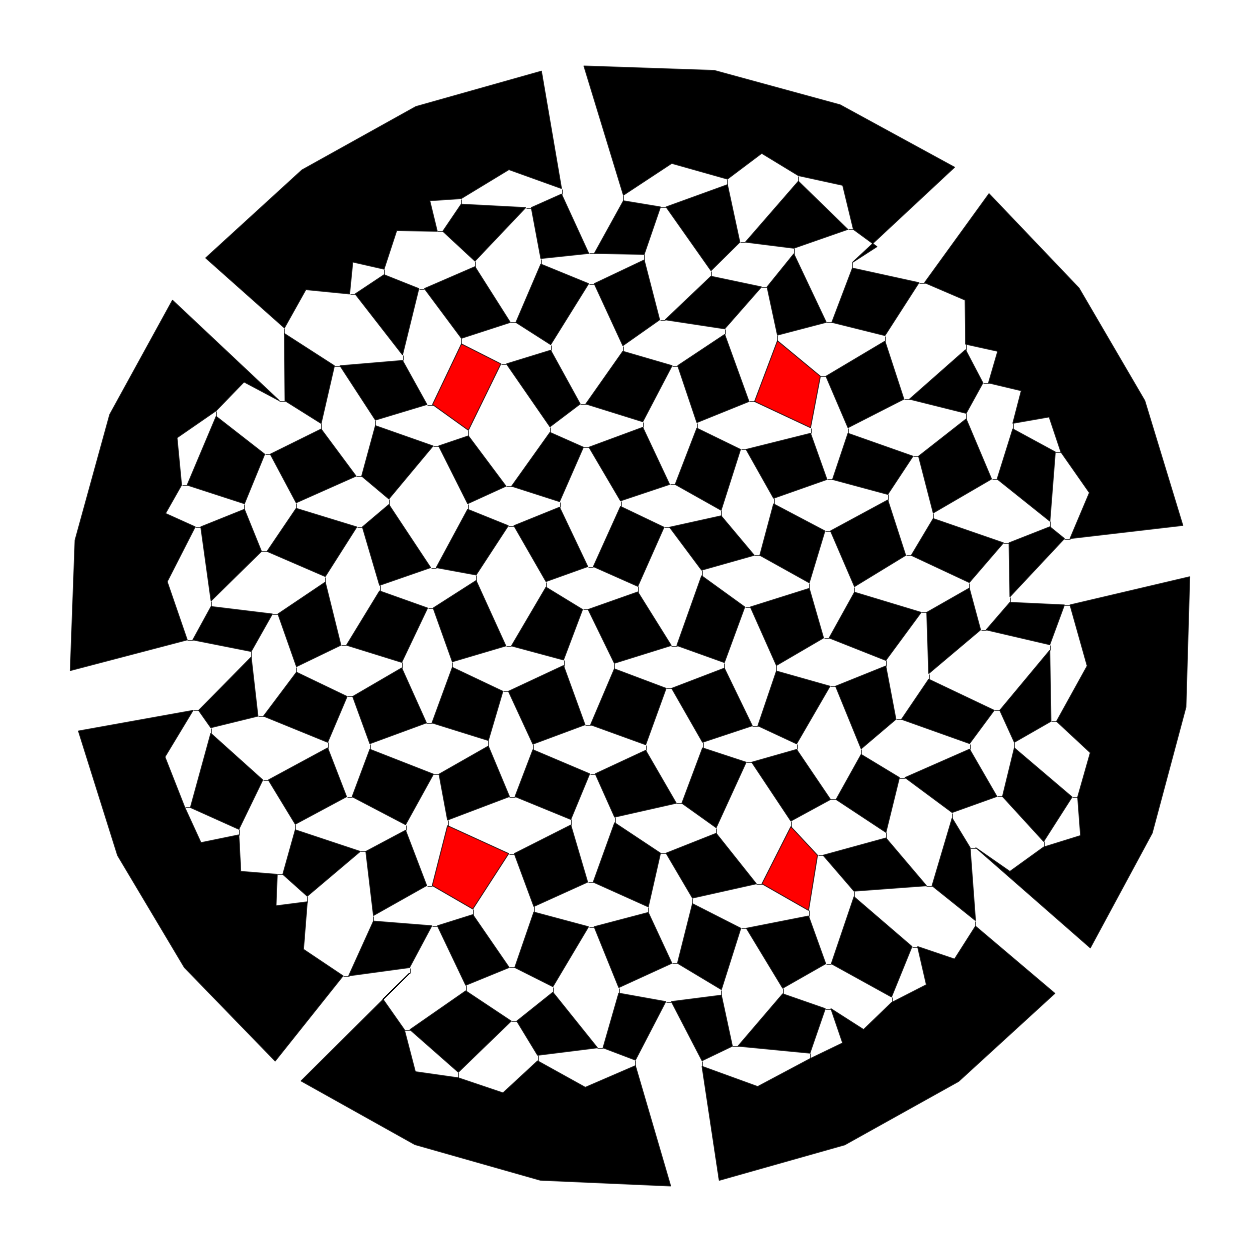

In [39]:
meta_params = param_record[min_idx]
measure_idx = [14, 18, 78, 82]
filename = f"Figure/122525_circular_structure_design_n1_blocks_{n1_blocks}_n2_blocks_{n2_blocks}_measure_idx_14_18_78_82_n_source_{n_source}_opt_design.eps"
plot_circle_structure(meta_params, measure_idx, save_fig=True, filename=filename)

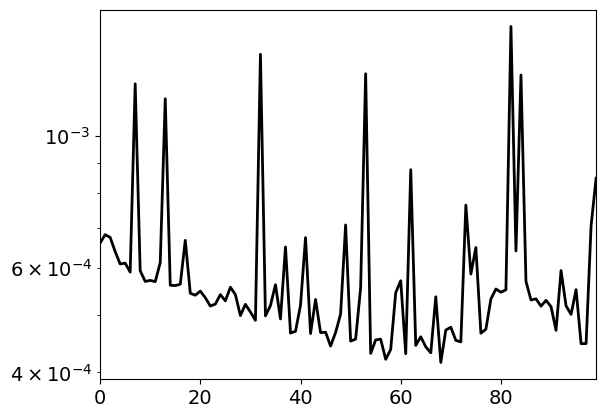

(1, 1, 15) (1, 1, 15)
(1, 1, 8) (1, 1, 8)
data min :  [[[-5.83610507e+03 -5.79412433e+03 -2.51130122e+00 -5.30976946e+03
   -6.77349703e+03 -3.08525908e+00 -6.30158652e+03 -5.58982232e+03
   -2.88327446e+00 -6.01509578e+03 -3.99077313e+03 -2.31682457e+00
   -5.07056293e+03 -6.04181438e+03 -2.64438020e+00]]]
data max :  [[[4.32410094e+03 4.99114576e+03 3.08413840e+00 6.13297826e+03
   4.53485914e+03 2.87452577e+00 5.15135494e+03 3.80621156e+03
   2.79005109e+00 7.33164303e+03 4.71202996e+03 3.31682049e+00
   4.97983586e+03 5.79742790e+03 2.23919039e+00]]]
test data min :  [[[-1.6038084  -1.58341525 -1.60596609 -1.61064834 -1.60504719
   -1.59252717 -1.60786702 -1.58384888]]]
test data max :  [[[-0. -0. -0. -0. -0. -0. -0. -0.]]]
Initial training loss : 6.2044e-04
Initial test loss : 6.6004e-04
Initial training loss in original scale : 1.5837e-03
Initial test loss in original scale : 1.6880e-03
--------------------------------
1.0 0.0
Optimized training loss : 4.2589e-04
Optimized test l

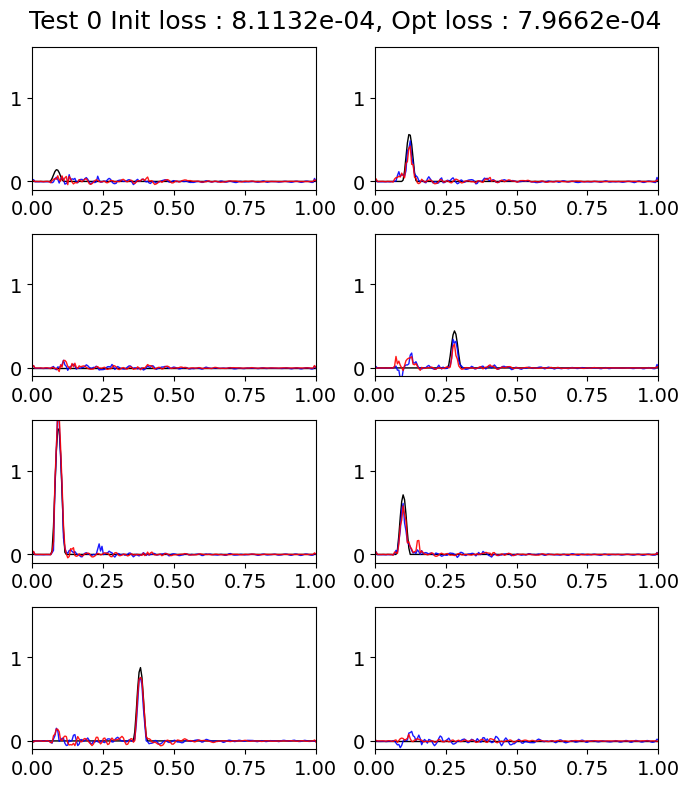

In [40]:
filename = f"03112026_circular_structure_cooptimization_n_source_16_measure_idx_24_28_45_51_70_exp_param_set_4_lr_0.1.pickle"
with open(filename, "rb") as f:
    record_dict = pickle.load(f)

param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), '-', lw=2, color=color_list[0])
plt.yscale('log')
# plt.savefig(f"Figure/circular_structure_loss_curve.eps")
plt.show()

filename = f"012326_circular_structure_dataset_n_source_8_exp_param_free_set_4_idx_24_28_45_51_70.pickle"
with open(filename, "rb") as f:
    data_dict = pickle.load(f)
input_data = data_dict["input_data"]
output_data = data_dict["output_data"]


min_idx = jnp.argmin(jnp.array(loss_record))
key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

mm_scaler = minmax_scaler(training_input_data, training_output_data)
mm_scaler.information()

params_init = in_param_record[0][0]
training_input_data = in_param_record[0][2]
training_output_data = in_param_record[0][3]
test_input_data = in_param_record[0][4]
test_output_data = in_param_record[0][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

model = TimeSeriesCNN(output_features=n_piece)
init_params = model.init(key, input_data)
preds = model.apply(init_params, input_data)

pred_y = model.apply(params_init, train_data_normalized)
pred_y_test = model.apply(params_init, test_data_normalized)

_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

mse = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Initial training loss : {mse:.4e}")
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Initial test loss : {mse_test:.4e}")

mse = jnp.mean((pred_y_org - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test - test_output_data)**2)
print(f"Initial training loss in original scale : {mse:.4e}")
print(f"Initial test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(output_data)

print("--------------------------------")
params_opt = in_param_record[min_idx][0]
training_input_data = in_param_record[min_idx][2]
training_output_data = in_param_record[min_idx][3]
test_input_data = in_param_record[min_idx][4]
test_output_data = in_param_record[min_idx][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
print( jnp.max(train_output_normalized), jnp.min(train_output_normalized) )

pred_y = model.apply(params_opt, train_data_normalized)
pred_y_test = model.apply(params_opt, test_data_normalized)

_, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)


mse = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Optimized training loss : {mse:.4e}")
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Optimized test loss : {mse_test:.4e}")

mse = jnp.mean((pred_y_org_opt - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test_opt - test_output_data)**2)
print(f"Optimized training loss in original scale : {mse:.4e}")
print(f"Optimized test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(jnp.concatenate([training_output_data, test_output_data]))
# color_list = ["#cc3f40", "#bdccd4", "#0b2456",]
color_list = ["k", "b", "r",]

N = 100
print("TEST")
for i in range(1):
    fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
    axes = axes.flatten()
    for j in range(n_piece):
        ax = axes[j]
        ax.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=1.0, label="True")
        ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], alpha=0.9, linewidth=1.0, label="Prediction from CNN")
        ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], alpha=0.9, linewidth=1.0, label="Prediction from CNN (optimized)")
        # ax.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=1.0, label="True")
        # ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], alpha=0.9, linewidth=0.75, label="Prediction from CNN")
        # ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], alpha=0.9, linewidth=0.75, label="Prediction from CNN (optimized)")
        ax.set_ylim(-0.1, -min_value)
        # plt.ylabel(f"Input {j+1}")
    init_loss = jnp.mean((pred_y_org_test[i] - test_output_data[i])**2)
    opt_loss = jnp.mean((pred_y_org_test_opt[i] - test_output_data[i])**2)
    plt.suptitle(f"Test {i} Init loss : {init_loss:.4e}, Opt loss : {opt_loss:.4e}")
    plt.tight_layout()
    # plt.savefig(f"Figure/Circular_structure/3_sensors_sim_init_opt_prediction_test_data_{i}.eps")
    # plt.savefig(f"Figure/Circular_structure/3_sensors_sim_init_opt_prediction_test_data_{i}.png")
    plt.show()

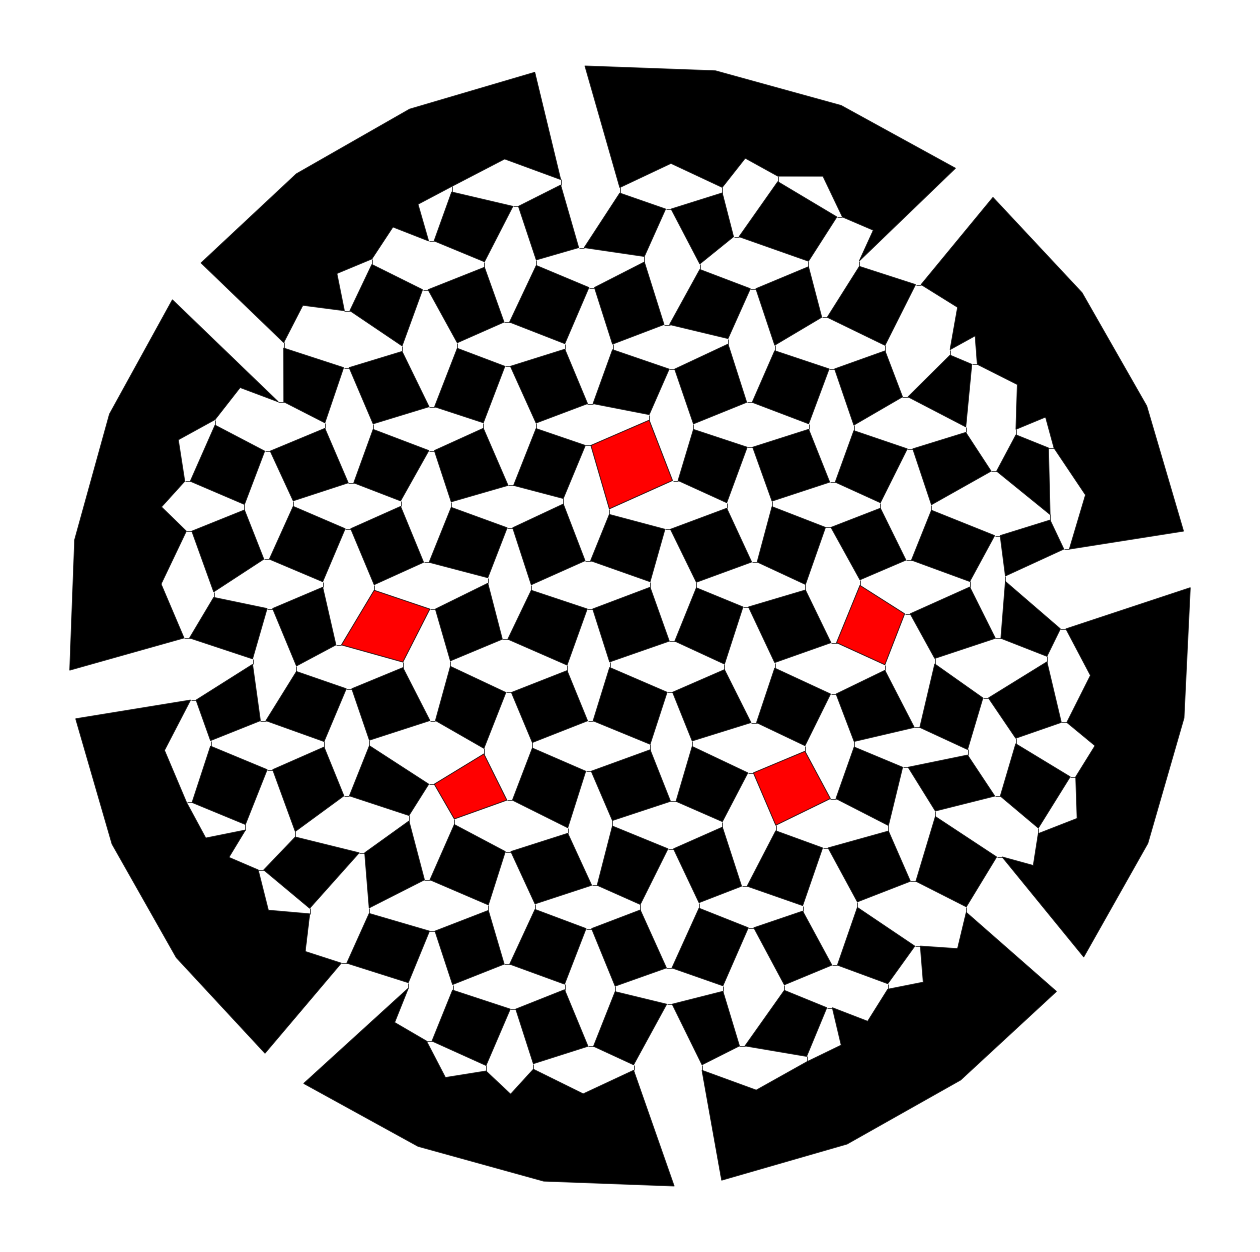

In [41]:
meta_params = param_record[min_idx]
measure_idx = [24, 28, 45, 51, 70]
filename = f"Figure/122525_circular_structure_design_n1_blocks_{n1_blocks}_n2_blocks_{n2_blocks}_measure_idx_24_28_45_51_70_n_source_{n_source}_opt_design.eps"
plot_circle_structure(meta_params, measure_idx, save_fig=True, filename=filename)

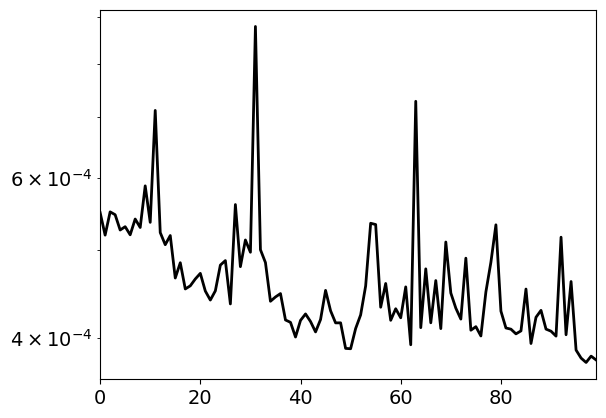

(1, 1, 18) (1, 1, 18)
(1, 1, 8) (1, 1, 8)
data min :  [[[-5.15172194e+03 -9.23514152e+03 -2.69954713e+00 -6.33399958e+03
   -5.19540633e+03 -3.33440213e+00 -4.93334383e+03 -6.09824134e+03
   -3.08390898e+00 -7.00293146e+03 -6.09436125e+03 -2.45513758e+00
   -5.36581243e+03 -4.07573001e+03 -2.94751944e+00 -5.11747697e+03
   -6.06276801e+03 -2.63675241e+00]]]
data max :  [[[4.39390671e+03 6.21818244e+03 3.30707727e+00 5.03080245e+03
   4.71974078e+03 3.30590418e+00 6.74248517e+03 5.15827589e+03
   3.58142198e+00 5.52298431e+03 4.84469648e+03 2.64236429e+00
   6.87146317e+03 5.37428773e+03 2.77394357e+00 4.98992486e+03
   5.75988343e+03 2.23151918e+00]]]
test data min :  [[[-1.6038084  -1.58341525 -1.60596609 -1.61064834 -1.60504719
   -1.59252717 -1.60786702 -1.58384888]]]
test data max :  [[[-0. -0. -0. -0. -0. -0. -0. -0.]]]
Initial training loss : 4.9876e-04
Initial test loss : 5.4936e-04
Initial training loss in original scale : 1.2723e-03
Initial test loss in original scale : 1.4050

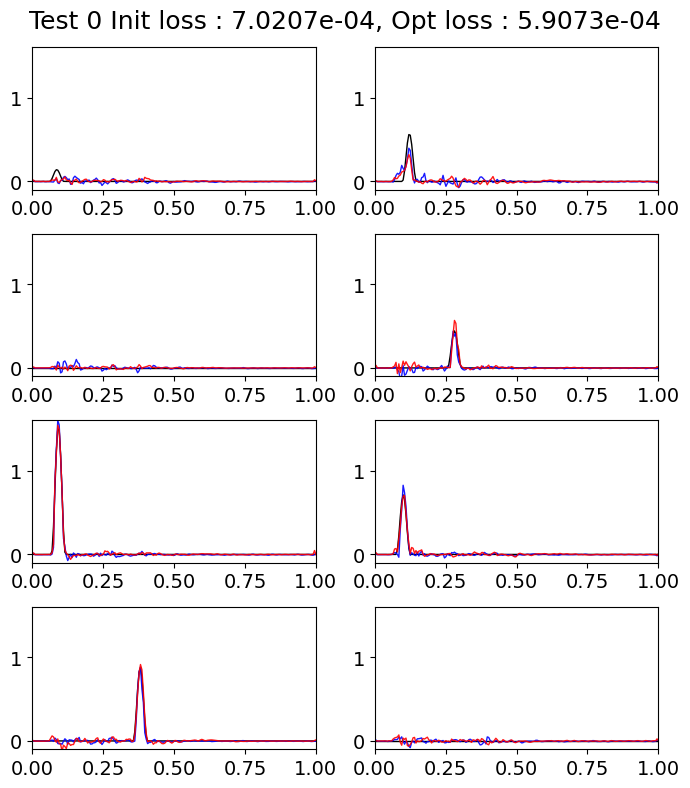

In [46]:
filename = f"03112026_circular_structure_cooptimization_n_source_16_measure_idx_16_23_29_56_62_70_exp_param_set_4_lr_0.1.pickle"
with open(filename, "rb") as f:
    record_dict = pickle.load(f)

param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), '-', lw=2, color=color_list[0])
plt.yscale('log')
# plt.savefig(f"Figure/circular_structure_loss_curve.eps")
plt.show()

filename = f"012326_circular_structure_dataset_n_source_8_exp_param_free_set_4_idx_16_23_29_56_62_70.pickle"
with open(filename, "rb") as f:
    data_dict = pickle.load(f)
input_data = data_dict["input_data"]
output_data = data_dict["output_data"]


min_idx = jnp.argmin(jnp.array(loss_record))
key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

mm_scaler = minmax_scaler(training_input_data, training_output_data)
mm_scaler.information()

params_init = in_param_record[0][0]
training_input_data = in_param_record[0][2]
training_output_data = in_param_record[0][3]
test_input_data = in_param_record[0][4]
test_output_data = in_param_record[0][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

model = TimeSeriesCNN(output_features=n_piece)
init_params = model.init(key, input_data)
preds = model.apply(init_params, input_data)

pred_y = model.apply(params_init, train_data_normalized)
pred_y_test = model.apply(params_init, test_data_normalized)

_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

mse = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Initial training loss : {mse:.4e}")
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Initial test loss : {mse_test:.4e}")

mse = jnp.mean((pred_y_org - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test - test_output_data)**2)
print(f"Initial training loss in original scale : {mse:.4e}")
print(f"Initial test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(output_data)

print("--------------------------------")
params_opt = in_param_record[min_idx][0]
training_input_data = in_param_record[min_idx][2]
training_output_data = in_param_record[min_idx][3]
test_input_data = in_param_record[min_idx][4]
test_output_data = in_param_record[min_idx][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
print( jnp.max(train_output_normalized), jnp.min(train_output_normalized) )

pred_y = model.apply(params_opt, train_data_normalized)
pred_y_test = model.apply(params_opt, test_data_normalized)

_, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)


mse = jnp.mean((pred_y - train_output_normalized)**2)
print(f"Optimized training loss : {mse:.4e}")
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"Optimized test loss : {mse_test:.4e}")

mse = jnp.mean((pred_y_org_opt - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test_opt - test_output_data)**2)
print(f"Optimized training loss in original scale : {mse:.4e}")
print(f"Optimized test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(jnp.concatenate([training_output_data, test_output_data]))
# color_list = ["#cc3f40", "#bdccd4", "#0b2456",]
color_list = ["k", "b", "r",]

N = 100
print("TEST")
for i in range(1):
    fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
    axes = axes.flatten()
    for j in range(n_piece):
        ax = axes[j]
        ax.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=1.0, label="True")
        ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], alpha=0.9, linewidth=1.0, label="Prediction from CNN")
        ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], alpha=0.9, linewidth=1.0, label="Prediction from CNN (optimized)")
        # ax.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=1.0, label="True")
        # ax.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], alpha=0.9, linewidth=0.75, label="Prediction from CNN")
        # ax.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], alpha=0.9, linewidth=0.75, label="Prediction from CNN (optimized)")
        ax.set_ylim(-0.1, -min_value)
        # plt.ylabel(f"Input {j+1}")
    init_loss = jnp.mean((pred_y_org_test[i] - test_output_data[i])**2)
    opt_loss = jnp.mean((pred_y_org_test_opt[i] - test_output_data[i])**2)
    plt.suptitle(f"Test {i} Init loss : {init_loss:.4e}, Opt loss : {opt_loss:.4e}")
    plt.tight_layout()
    # plt.savefig(f"Figure/Circular_structure/3_sensors_sim_init_opt_prediction_test_data_{i}.eps")
    # plt.savefig(f"Figure/Circular_structure/3_sensors_sim_init_opt_prediction_test_data_{i}.png")
    plt.show()

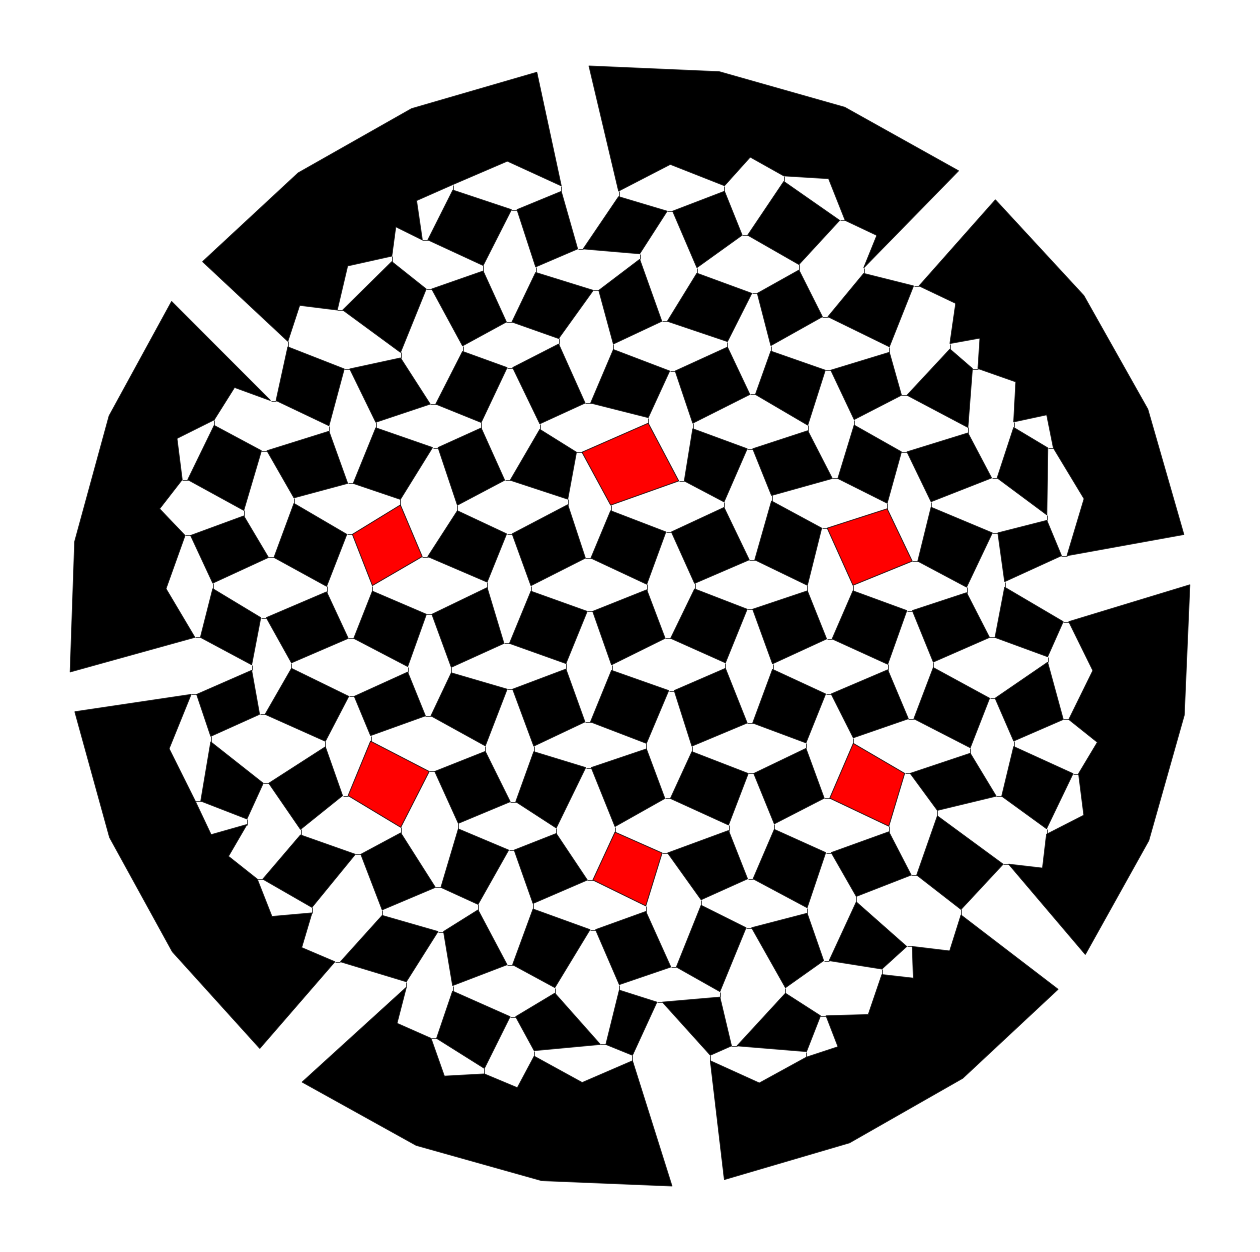

In [47]:
meta_params = param_record[min_idx]
measure_idx = [16, 23, 29, 56, 62, 70]
filename = f"Figure/122525_circular_structure_design_n1_blocks_{n1_blocks}_n2_blocks_{n2_blocks}_measure_idx_16_23_29_56_62_70_n_source_{n_source}_opt_design.eps"
plot_circle_structure(meta_params, measure_idx, save_fig=True, filename=filename)

In [ ]:
meta_params = param_record[min_idx]
measure_idx = [24, 28, 45, 51, 70]
filename = f"Figure/122525_circular_structure_design_n1_blocks_{n1_blocks}_n2_blocks_{n2_blocks}_measure_idx_24_28_45_51_70_n_source_{n_source}_opt_design.eps"
plot_circle_structure(meta_params, measure_idx, save_fig=True, filename=filename)

meta_params = param_record[min_idx]
measure_idx = [16, 23, 29, 56, 62, 70]
filename = f"Figure/122525_circular_structure_design_n1_blocks_{n1_blocks}_n2_blocks_{n2_blocks}_measure_idx_16_23_29_56_62_70_n_source_{n_source}_opt_design.eps"
plot_circle_structure(meta_params, measure_idx, save_fig=True, filename=filename)

,Init. Training loss,Init. Test loss,Opt. Training,Opt. Test
# Sensors,,,,
1,0.008009,0.007546,0.006198,0.004781
2,0.004482,0.004209,0.003068,0.002337
3,0.002543,0.002335,0.001604,0.001322
4,0.001499,0.001490,0.001010,0.000887
5,0.001584,0.001688,0.001089,0.001064
6,0.001272,0.001405,0.001022,0.000961


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


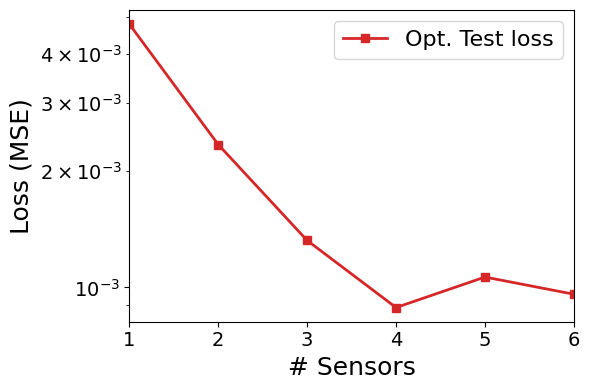

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    "Init. Training loss": [8.0090e-03, 4.4819e-03, 2.5429e-03, 1.4987e-03, 1.5837e-03, 1.2723e-03],
    "Init. Test loss":     [7.5461e-03, 4.2088e-03, 2.3348e-03, 1.4901e-03, 1.6880e-03, 1.4050e-03],
    "Opt. Training":       [6.1984e-03, 3.0677e-03, 1.6042e-03, 1.0103e-03, 1.0888e-03, 1.0221e-03],
    "Opt. Test":           [4.7806e-03, 2.3369e-03, 1.3221e-03, 8.8739e-04, 1.0638e-03, 9.6052e-04],
}

df = pd.DataFrame(data)
df.index = np.arange(1, len(df) + 1)
df.index.name = "# Sensors"
display(df)

fig, ax = plt.subplots(figsize=(6, 4))
# ax.plot(df.index, df["Init. Test loss"], "o-", color="tab:blue", label="Init. Test loss")
ax.plot(df.index, df["Opt. Test"], "s-", color="tab:red", label="Opt. Test loss")
ax.set_xlabel("# Sensors")
ax.set_ylabel("Loss (MSE)")
ax.set_xticks(df.index)
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.savefig(f"Figure/Circular_structure/circular_structure_loss_curve_number_of_sensors.png")
plt.savefig(f"Figure/Circular_structure/circular_structure_loss_curve_number_of_sensors.eps")
plt.show()

In [ ]:
def show_results_multi(
    fname_list,
    N=4,
    save_fig=False,
    folder="Circular_structure",
    name="",
    idx_list=None,
    file_labels=None,
    show_initial=False,
    reference_run=0,
    timeseries_view="peak",
    peak_half_width=20,
):
    """Load each pickle in ``fname_list`` and overlay predictions on one figure per test index.

    Ground truth and (for ``timeseries_view="peak"``) peak windows are taken from
    ``reference_run`` (default: first file) so curves align in time. Relative errors in the
    title are vs. that same reference truth.

    timeseries_view:
        ``"peak"`` — zoom to ``[peak - peak_half_width, peak + peak_half_width]`` per channel
        (peak from reference truth).
        ``"full"`` — plot the entire time axis for each channel.
    """
    n_runs = len(fname_list)
    if idx_list is None:
        idx_list = [f"File {k}" for k in range(n_runs)]
    if len(idx_list) != n_runs:
        raise ValueError("idx_list must have the same length as fname_list")
    if file_labels is None:
        file_labels = [str(x) for x in idx_list]
    if reference_run < 0 or reference_run >= n_runs:
        raise ValueError("reference_run must be an index into fname_list")
    if timeseries_view not in ("peak", "full"):
        raise ValueError('timeseries_view must be "peak" or "full"')

    n_piece = 8
    color_true = "k" # "#cc3f40"
    color_init = "#bdccd4"
    color_opt_single = "#0b2456"
    color_list = ["#d26766", "#6bb150", "#e4c55f", "#a74f94", "#c6c72e","#f69a47"]

    runs = []
    for k in range(n_runs):
        filename = f"012326_circular_structure_dataset_n_source_8_exp_param_free_set_4_idx_{idx_list[k]}.pickle"
        print(f"[run {k}] dataset:", filename, "| record:", fname_list[k])
        with open(filename, "rb") as f:
            data_dict = pickle.load(f)
        if k==0:
            measure_idx = jnp.array([48])
            input_data = jnp.zeros_like(data_dict["input_data"][:,:,2,measure_idx,:].squeeze()) # (N, time_steps, 3)
            input_data = input_data.at[:,:,0:2].set(data_dict["input_data"][:,:,2,measure_idx,0:2].squeeze()) # (N, time_steps, 2)
            input_data = input_data.at[:,:,2].set(data_dict["input_data"][:,:,1,measure_idx,2].squeeze()) # (N, time_steps, 2)
            output_data = data_dict["output_data"]
        else:
            input_data = data_dict["input_data"]
            output_data = data_dict["output_data"]

        with open(fname_list[k], "rb") as f:
            record_dict = pickle.load(f)

        print(f"[run {k}] keys:", record_dict.keys())

        in_param_record = record_dict["nn_record"]
        loss_record = record_dict["loss_record"]

        min_idx = jnp.argmin(jnp.array(loss_record))
        key = random.PRNGKey(0)
        test_N = input_data.shape[0] // 10
        test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
        mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)
        training_input_data = input_data[mask]
        training_output_data = output_data[mask]

        mm_scaler = minmax_scaler(training_input_data, training_output_data)
        mm_scaler.information()

        params_init = in_param_record[0][0]
        training_input_data = in_param_record[0][2]
        training_output_data = in_param_record[0][3]
        test_input_data = in_param_record[0][4]
        test_output_data = in_param_record[0][5]

        train_data_normalized, train_output_normalized = mm_scaler.transform(
            training_input_data, training_output_data
        )
        test_data_normalized, test_output_normalized = mm_scaler.transform(
            test_input_data, test_output_data
        )

        model = TimeSeriesCNN(output_features=n_piece)
        init_params = model.init(key, input_data)

        pred_y = model.apply(params_init, train_data_normalized)
        pred_y_test = model.apply(params_init, test_data_normalized)
        _, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

        mse = jnp.mean((pred_y_test - test_output_normalized) ** 2)
        print(f"[run {k}] initial test loss (normalized): {mse:.4e}")

        params_opt = in_param_record[min_idx][0]
        training_input_data = in_param_record[min_idx][2]
        training_output_data = in_param_record[min_idx][3]
        test_input_data = in_param_record[min_idx][4]
        test_output_data = in_param_record[min_idx][5]

        train_data_normalized, train_output_normalized = mm_scaler.transform(
            training_input_data, training_output_data
        )
        test_data_normalized, test_output_normalized = mm_scaler.transform(
            test_input_data, test_output_data
        )

        pred_y_test = model.apply(params_opt, test_data_normalized)
        _, pred_y_org_test_opt = mm_scaler.inverse_transform(
            test_data_normalized, pred_y_test
        )

        mse_test = jnp.mean((pred_y_test - test_output_normalized) ** 2)
        mse_test_org = jnp.mean(
            (pred_y_org_test_opt - test_output_data) ** 2
        )
        print(f"[run {k}] optimized test loss (normalized): {mse_test:.4e}")
        print(f"[run {k}] optimized test loss (original scale): {mse_test_org:.4e}")

        runs.append(
            {
                "test_output_data": test_output_data,
                "pred_y_org_test": pred_y_org_test,
                "pred_y_org_test_opt": pred_y_org_test_opt,
                "label": file_labels[k],
            }
        )

    ref = runs[reference_run]["test_output_data"]
    random_idx_test = jnp.arange(0, N, 1)

    cmp_suffix = "__".join(str(x) for x in idx_list)
    view_tag = "full" if timeseries_view == "full" else f"peak_w{peak_half_width}"
    max_value = float(jnp.max(-ref)) * 1.1
    print(
        "n_piece:",
        n_piece,
        "| overlay",
        n_runs,
        "runs | reference truth: run",
        reference_run,
        "| view:",
        timeseries_view,
    )
    for idx in random_idx_test:
        step_set = []
        for j in range(n_piece):
            peak_idx = int(jnp.argmax(-ref[idx, :, j]))
            step_set.append(peak_idx)
        if timeseries_view == "peak":
            print(f"test idx {int(idx)} peak indices:", step_set)

        fig_w = (11 if timeseries_view == "full" else 7) + 1.2 * max(0, n_runs - 1)
        fig, axes = plt.subplots(n_piece // 2, 2, figsize=(fig_w, 1.0 * n_piece))
        axes = axes.flatten()

        for j in range(n_piece):
            ax = axes[j]
            if timeseries_view == "full":
                sl = slice(None)
                tseg = ts
            else:
                peak_idx = step_set[j]
                if peak_idx - peak_half_width < 0:
                    peak_idx = peak_half_width
                sl = slice(peak_idx - peak_half_width, peak_idx + peak_half_width)
                tseg = ts[sl]

            ax.plot(
                tseg,
                -ref[idx, sl, j],
                color=color_true,
                linewidth=0.9,
                label="True" if j == 0 else None,
            )

            for rk, run in enumerate(runs):
                if n_runs == 1:
                    ax.plot(
                        tseg,
                        -run["pred_y_org_test"][idx, sl, j],
                        color=color_init,
                        alpha=0.9,
                        linewidth=0.5,
                        label="Prediction from CNN" if j == 0 else None,
                    )
                    ax.plot(
                        tseg,
                        -run["pred_y_org_test_opt"][idx, sl, j],
                        color=color_opt_single,
                        alpha=0.9,
                        linewidth=0.5,
                        label="Prediction from CNN (optimized)" if j == 0 else None,
                    )
                else:
                    c = color_list[rk % len(color_list)]
                    if show_initial:
                        ax.plot(
                            tseg,
                            -run["pred_y_org_test"][idx, sl, j],
                            color=c,
                            alpha=0.35,
                            linewidth=0.55,
                            linestyle="--",
                            label=f'{run["label"]} (init)' if j == 0 else None,
                        )
                    ax.plot(
                        tseg,
                        -run["pred_y_org_test_opt"][idx, sl, j],
                        color=c,
                        alpha=0.95,
                        linewidth=0.75,
                        label=run["label"] if j == 0 else None,
                    )

            if timeseries_view == "peak" and step_set[j] == 0:
                ax.set_ylim(-0.1, max_value)
            ax.set_ylabel(f"Input {j+1}")

        err_parts = []
        for rk, run in enumerate(runs):
            rel = jnp.sum(
                (ref[idx, :, :] - run["pred_y_org_test_opt"][idx, :, :]) ** 2
            ) / jnp.sum(ref[idx, :, :] ** 2) * 100.0
            err_parts.append(f'{file_labels[rk]}: {float(rel):.2f}%')
        title = f"{name}Test {int(idx)} | {timeseries_view} | " + " | ".join(err_parts)
        if n_runs == 1:
            run = runs[0]
            rel_i = jnp.sum(
                (ref[idx, :, :] - run["pred_y_org_test"][idx, :, :]) ** 2
            ) / jnp.sum(ref[idx, :, :] ** 2) * 100.0
            title += f" (init: {float(rel_i):.2f}%)"

        plt.suptitle(title)
        plt.tight_layout()
        h, l = axes[0].get_legend_handles_labels()
        if h:
            fig.legend(h, l, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
        plt.subplots_adjust(right=0.82)

        if save_fig:
            base = f"Figure/{folder}/sim_multi_prediction_{view_tag}_test_{int(idx)}_{cmp_suffix}"
            plt.savefig(f"{base}.eps", bbox_inches="tight")
            plt.savefig(f"{base}.png", bbox_inches="tight")
        plt.show()

configs = [
    ([(48,)],            ["01302026"], 1),
    ([(28, 68)],            ["02262026"], 1),
    ([(24, 28, 70)],            ["02262026"], 1),
    ([(14, 18, 78, 82)],            ["03102026"], 1),
    ([(24, 28, 45, 51, 70)],            ["03112026"], 1),
    ([(16, 23, 29, 56, 62, 70)],            ["03112026"], 1),
]

fname_list = []
idx_list = []

for idx_set, date_set, k in configs:
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        idx_str = ",".join(str(x) for x in idx_tuple)
        file_idx = "_".join(str(x) for x in idx_tuple)
        # 03102026_circular_structure_cooptimization_n_source_16_measure_idx_14_18_78_82_exp_param_set_4_lr_0.1
        fname = f"{date}_circular_structure_cooptimization_n_source_16"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}_exp_param_set_4_lr_0.1"
        fname += ".pickle"
    fname_list.append(fname)
    idx_list.append(file_idx)

show_results_multi(fname_list, N=30, save_fig=True, folder="Circular_structure/all", idx_list=idx_list, timeseries_view="peak")
 

In [37]:
def show_results_multi(fname_list, N=4, save_fig=False, folder="Circular_structure", name="", idx_list=None, source_num=4):
    if idx_list is None:
        idx_list = [f"File {k}" for k in range(len(fname_list))]

    for k in range(len(fname_list)):
        n_piece = 8
        filename = f"012326_circular_structure_dataset_n_source_8_exp_param_free_set_4_idx_{idx_list[k]}.pickle"
        print("Checking for data file at:", filename)
        with open(filename, "rb") as f:
            data_dict = pickle.load(f)
        input_data = data_dict["input_data"]
        output_data = data_dict["output_data"]

        fname = fname_list[k]
        with open(fname, "rb") as f:
            record_dict = pickle.load(f)

        print(record_dict.keys())

        param_record = record_dict["design_record"]
        in_param_record = record_dict["nn_record"]
        loss_record = record_dict["loss_record"]


        min_idx = jnp.argmin(jnp.array(loss_record))
        key = random.PRNGKey(0)
        test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
        test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

        mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

        training_input_data = input_data[mask]
        training_output_data = output_data[mask]

        test_input_data = input_data[test_idx]
        test_output_data = output_data[test_idx]

        mm_scaler = minmax_scaler(training_input_data, training_output_data)
        mm_scaler.information()

        params_init = in_param_record[0][0]
        training_input_data = in_param_record[0][2]
        training_output_data = in_param_record[0][3]
        test_input_data = in_param_record[0][4]
        test_output_data = in_param_record[0][5]

        train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
        test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

        model = TimeSeriesCNN(output_features=n_piece)
        init_params = model.init(key, input_data)
        preds = model.apply(init_params, input_data)

        pred_y = model.apply(params_init, train_data_normalized)
        pred_y_test = model.apply(params_init, test_data_normalized)

        _, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
        _, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

        mse = jnp.mean((pred_y - train_output_normalized)**2)
        mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
        print(f"Initial training loss : {mse:.4e}")
        print(f"Initial test loss : {mse_test:.4e}")

        mse = jnp.mean((pred_y_org - training_output_data)**2)
        mse_test = jnp.mean((pred_y_org_test - test_output_data)**2)
        print(f"Initial training loss in original scale : {mse:.4e}")
        print(f"Initial test loss in original scale : {mse_test:.4e}")

        params_opt = in_param_record[min_idx][0]
        training_input_data = in_param_record[min_idx][2]
        training_output_data = in_param_record[min_idx][3]
        test_input_data = in_param_record[min_idx][4]
        test_output_data = in_param_record[min_idx][5]

        train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
        test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
        print( jnp.max(train_output_normalized), jnp.min(train_output_normalized) )

        pred_y = model.apply(params_opt, train_data_normalized)
        pred_y_test = model.apply(params_opt, test_data_normalized)

        _, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
        _, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

        mse = jnp.mean((pred_y - train_output_normalized)**2)
        mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
        print(f"Optimized training loss : {mse:.4e}")
        print(f"Optimized test loss : {mse_test:.4e}")

        mse = jnp.mean((pred_y_org_opt - training_output_data)**2)
        mse_test = jnp.mean((pred_y_org_test_opt - test_output_data)**2)
        print(f"Optimized training loss in original scale : {mse:.4e}")
        print(f"Optimized test loss in original scale : {mse_test:.4e}")

        print("min value : ", mm_scaler.output_data_min)
        min_value = jnp.min(mm_scaler.output_data_min)

        color_list = ["#cc3f40", "#bdccd4", "#0b2456",]
        # print("TEST")
        # for idx in random_idx_test:
        #     plt.figure(figsize=(10,1.5*n_source))
        #     min_value = jnp.min(test_output[idx,:,:]) * 1.5
        #     for j in range(n_source):
        #         plt.subplot(n_source//2,2,1+j)
        #         plt.plot( ts, -test_output[idx,:,j], color=color_list[0], label="True")
        #         # plt.plot( ts, -pred_y_test_org[i,:,j], color=color_list[1], label="Initial design")
        #         plt.plot( ts, -pred_y_test_opt_org[idx,:,j], color=color_list[2], label="Optimized design")
        #         # plt.xlim(0,0.4)
        #         # plt.ylim(min_value, 1e-1)
        #         plt.ylim(-5e-2, -min_value)
        #         plt.ylabel(f"Input {j+1}")
        #     relative_error = jnp.sum((test_output[idx,:,:]-pred_y_test_opt_org[idx,:,:])**2)/jnp.sum(test_output[idx,:,:]**2)*100.0
        #     # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
        #     # plt.legend()
        #     plt.suptitle(f"{name} Test {idx} relative error: {relative_error:.2f}%")
        #     plt.tight_layout()
        #     if save_fig:
        #         plt.savefig(f'Figure/{folder}/{name}Test_{idx}.eps', bbox_inches='tight')
        #     plt.show()

        random_idx_test = jnp.arange(0,N,1)
        
        T = 20
        
        print("n_piece : ", n_piece)
        for idx in random_idx_test:
            step_set = []
            for j in range(n_piece):
                peak_idx = jnp.argmax(-test_output_data[idx, :, j])
                # print(peak_idx)
                step_set.append(peak_idx)
            print(step_set)
            # min_value = jnp.min(test_output_data[idx,:,:]) * 1.4
            # plt.figure(figsize=(7,1.*n_piece))
            fig, axes = plt.subplots(n_piece//2,2, figsize=(7,1.*n_piece))
            axes = axes.flatten()
            for j in range(n_piece):
                ax = axes[j]
                peak_idx = step_set[j]
                if peak_idx - T < 0:
                    peak_idx = T
                # print(peak_idx)
                ax.plot( ts[peak_idx-T:peak_idx+T], -test_output_data[idx,peak_idx-T:peak_idx+T,j],  color=color_list[0],linewidth=0.5,label="True")
                ax.plot( ts[peak_idx-T:peak_idx+T], -pred_y_org_test[idx,peak_idx-T:peak_idx+T,j], color=color_list[1],  alpha=0.9, linewidth=0.5, label="Prediction from CNN")
                ax.plot( ts[peak_idx-T:peak_idx+T], -pred_y_org_test_opt[idx,peak_idx-T:peak_idx+T,j], color=color_list[2], alpha=0.9, linewidth=0.5, label="Prediction from CNN (optimized)")
                if step_set[j] == 0:
                    ax.set_ylim(-0.1, 1.0)
                # ax.set_ylim(-0.1, -min_value)
                ax.set_ylabel(f"Input {j+1}")
                # ax.set_xticklabels([])
                # ax.set_yticklabels([])
            relative_error = jnp.sum((test_output_data[idx,:,:]-pred_y_org_test_opt[idx,:,:])**2)/jnp.sum(test_output_data[idx,:,:]**2)*100.0    
            relative_error_init = jnp.sum((test_output_data[idx,:,:]-pred_y_org_test[idx,:,:])**2)/jnp.sum(test_output_data[idx,:,:]**2)*100.0
            # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
            # plt.legend()
            plt.suptitle(f"Test {idx} relative error: {relative_error:.2f}% (initial: {relative_error_init:.2f}%)")
            plt.tight_layout()
            plt.savefig(f"Figure/Circular_structure/111925_sim_opt_init_prediction_test_data_{idx}_{idx_list[k]}.eps")
            plt.savefig(f"Figure/Circular_structure/111925_sim_opt_init_prediction_test_data_{idx}_{idx_list[k]}.png")
            plt.show()

In [ ]:
fname_list = [f"03102026_circular_structure_cooptimization_n_source_16_measure_idx_14_18_78_82_exp_param_set_4_lr_0.1.pickle"]
show_results_multi(fname_list, N=30, save_fig=True, name="circular_structure_4_sensors_14_18_78_82_", idx_list=["14_18_78_82"])


## 16 shells and 8 sensors

### Large-size cooptimization results (`112025_cooptimization_circular_structure_exp_param_large_size.py`)

Run this after the imports / `minmax_scaler` / `TimeSeriesCNN` cells.

- Edit **RECORD_PICKLE** to your saved pickle (pattern: `MMDDYYYY_circular_structure_cooptimization_n_source_<2*n_piece>_measure_idx_..._exp_param_lr_<lr>.pickle`; for `n_piece=16`, `n_source=32`).
- Set **MEASURE_IDX** to the same values as `--measure-idx` when you ran the script.
- Geometry is rebuilt here to match the script (`n_piece=16`, 15×15 grid, spacing/bond length as in the script), independent of the earlier `n_piece=8` notebook cell.
- The code aligns **geometry** with **design_record[design_idx]** and **CNN state** with **nn_record[best_loss_idx]** (outer loss is logged after each design update).


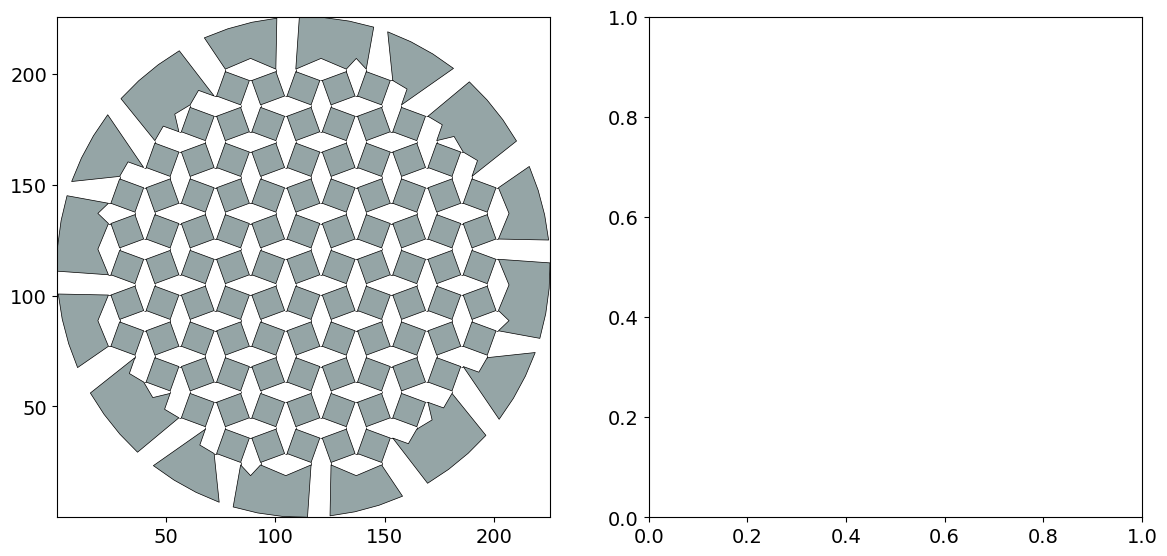

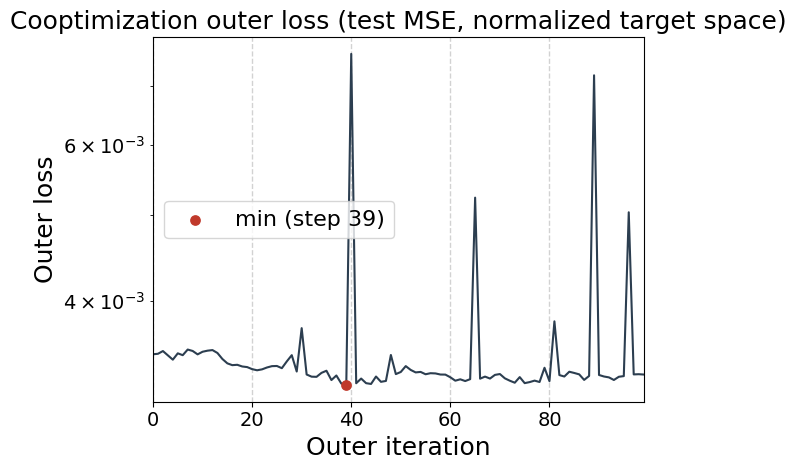

In [ ]:
fig, ax = plt.subplots()
ax.plot(jnp.arange(len(loss_record)), loss_record, color="#2c3e50", lw=1.5)
ax.scatter(best_loss_idx, float(loss_record[best_loss_idx]), c="#c0392b", s=45, zorder=3, label=f"min (step {best_loss_idx})")
ax.set_xlabel("Outer iteration")
ax.set_ylabel("Outer loss")
ax.set_title("Cooptimization outer loss (test MSE, normalized target space)")
ax.legend()
ax.grid(True, alpha=0.35)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print("initial loss:")

In [12]:
geometry_ls.n_blocks

113

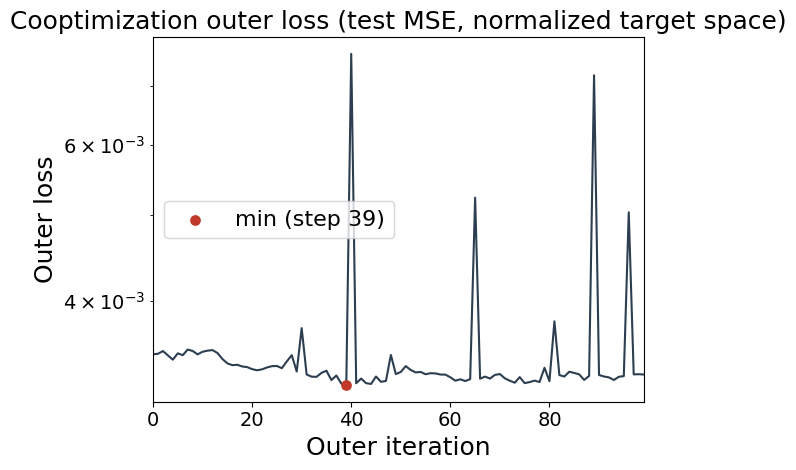

initial loss:  0.0034858236431437903
best loss:  0.0032171320313553087


/tmp/ipykernel_285327/3478414744.py:108: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_i.legend(loc="upper right", fontsize=10)


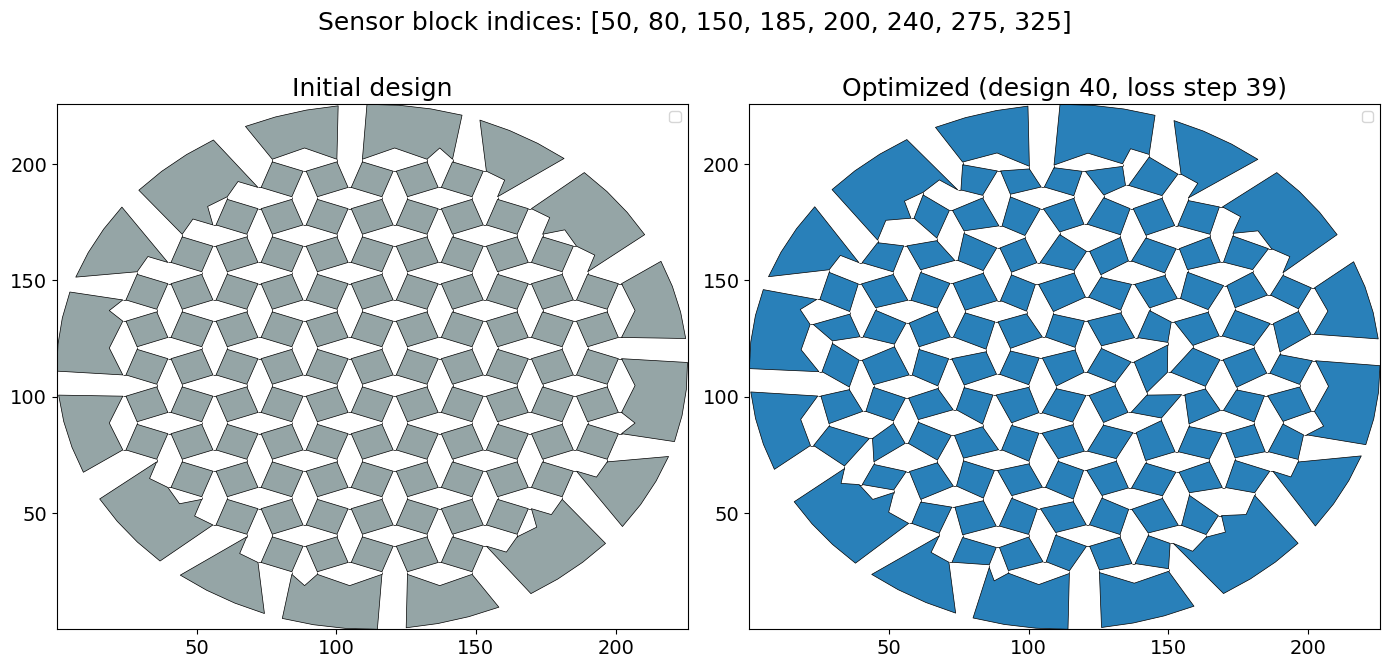

(1, 1, 24) (1, 1, 24)
(1, 1, 16) (1, 1, 16)


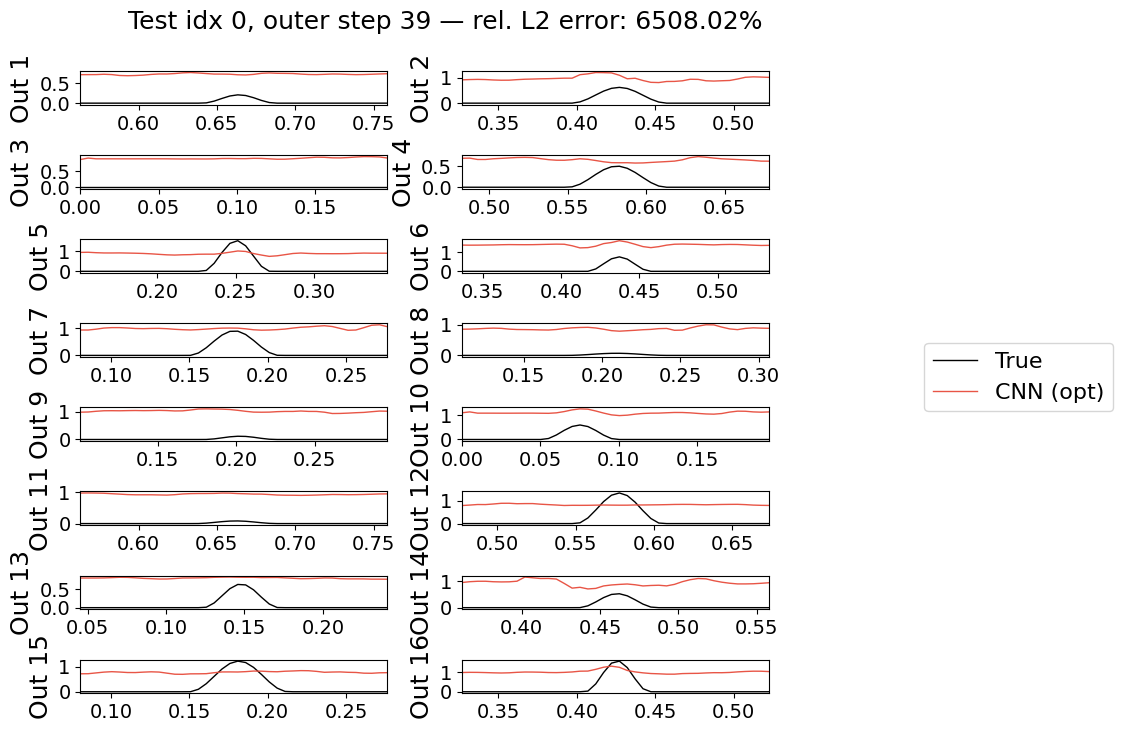

In [10]:
# --- Visualize results from 112025_cooptimization_circular_structure_exp_param_large_size.py ---
import pickle
from pathlib import Path

from blockymetamaterials.geometry import QuadGeometry_Circle_InputSource
from blockymetamaterials.plotting_input import plot_geometry

# -----------------------------------------------------------------------------
# User: set paths to match your run (see script save line: time_string + ...)
# -----------------------------------------------------------------------------
RECORD_PICKLE = "04032026_circular_structure_cooptimization_n_source_32_measure_idx_50_80_150_185_200_240_275_325_exp_param_lr_0.1.pickle"
MEASURE_IDX = jnp.array([50, 80, 150, 185, 200, 240, 275, 325])  # same as --measure-idx

# Geometry / model layout — must match 112025_cooptimization_circular_structure_exp_param_large_size.py
n1_blocks = 15
n2_blocks = 15
n_piece = 16
n_source = n_piece * 2
spacing = 15.0 + 0.075 * 15.0
hinge_length = 0.075 * 15.0
initial_angle = 25.0 * jnp.pi / 180.0
bond_length = hinge_length
simulation_time = 1.0
n_timepoints = 200
ts_viz = jnp.linspace(0, simulation_time, n_timepoints)

hori_shifts_length = (n1_blocks + 1) * n2_blocks * 2

geometry_ls = QuadGeometry_Circle_InputSource(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=bond_length,
    n_piece=n_piece,
)
block_centroids_fn, centroid_node_vectors_fn, bond_connectivity_fn, _ref_fn = geometry_ls.get_parametrization()
bond_connectivity_arr = bond_connectivity_fn()

horizontal_shifts_init, vertical_shifts_init = QuadGeometry_Circle_InputSource(
    n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_piece=n_piece
).get_design_from_rotated_square(angle=initial_angle)

centroids_init = block_centroids_fn(horizontal_shifts_init, vertical_shifts_init)
centroid_vecs_init = centroid_node_vectors_fn(horizontal_shifts_init, vertical_shifts_init)

record_path = Path(RECORD_PICKLE)
if not record_path.is_file():
    raise FileNotFoundError(f"Cooptimization pickle not found: {record_path.resolve()}")

with open(record_path, "rb") as f:
    record_dict = pickle.load(f)

loss_record = jnp.array(record_dict["loss_record"])
design_record = record_dict["design_record"]
nn_record = record_dict["nn_record"]
# loss_record[k] is after outer step k; matching layout is design_record[k+1] when present.
best_loss_idx = int(jnp.argmin(loss_record))
design_idx = min(best_loss_idx + 1, len(design_record) - 1)

# ----------------------------------------------------------------------------- 
# 1) Outer loss vs iteration
# ----------------------------------------------------------------------------- 
fig, ax = plt.subplots()
ax.plot(jnp.arange(len(loss_record)), loss_record, color="#2c3e50", lw=1.5)
ax.scatter(best_loss_idx, float(loss_record[best_loss_idx]), c="#c0392b", s=45, zorder=3, label=f"min (step {best_loss_idx})")
ax.set_xlabel("Outer iteration")
ax.set_ylabel("Outer loss")
ax.set_title("Cooptimization outer loss (test MSE, normalized target space)")
ax.legend()
# ax.grid(True, alpha=0.35)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print( "initial loss: ", loss_record[0])
print("best loss: ", loss_record[best_loss_idx])

# ----------------------------------------------------------------------------- 
# 2) Initial vs optimized structure with sensor locations
# ----------------------------------------------------------------------------- 
meta = jnp.asarray(design_record[design_idx])
hs_opt = meta[:hori_shifts_length].reshape((n1_blocks + 1, n2_blocks, 2))
vs_opt = meta[hori_shifts_length:].reshape((n1_blocks, n2_blocks + 1, 2))

centroids_opt = block_centroids_fn(hs_opt, vs_opt)
centroid_vecs_opt = centroid_node_vectors_fn(hs_opt, vs_opt)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
for ax_i, cents, vecs, title, color in [
    (axes[0], centroids_init, centroid_vecs_init, "Initial design", "#95a5a6"),
    (axes[1], centroids_opt, centroid_vecs_opt, f"Optimized (design {design_idx}, loss step {best_loss_idx})", "#2980b9"),
]:
    plot_geometry(cents, vecs, bond_connectivity_arr, color=color, ax=ax_i)
    # mx = cents[MEASURE_IDX, 0]
    # my = cents[MEASURE_IDX, 1]
    # ax_i.scatter(
    #     mx,
    #     my,
    #     c="#e74c3c",
    #     s=140,
    #     marker="*",
    #     zorder=10,
    #     edgecolors="k",
    #     linewidths=0.6,
    #     label="Sensors",
    # )
    ax_i.set_title(title)
    ax_i.legend(loc="upper right", fontsize=10)
plt.suptitle(f"Sensor block indices: {MEASURE_IDX.tolist()}", y=1.02)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------- 
# 3) CNN prediction vs true (stored test split for best outer iteration)
# ----------------------------------------------------------------------------- 
params_opt, _inner_state, tr_in, tr_out, te_in, te_out = nn_record[best_loss_idx]

mm_viz = minmax_scaler(tr_in, tr_out)
te_in_n, te_out_n = mm_viz.transform(te_in, te_out)
pred_n = TimeSeriesCNN(output_features=n_piece).apply(params_opt, te_in_n)
_, pred_org = mm_viz.inverse_transform(te_in_n, pred_n)

test_idx_plot = 0
peak_half = 20
fig, axes = plt.subplots(n_piece // 2, 2, figsize=(9, 0.45 * n_piece))
axes = axes.flatten()
for ch in range(n_piece):
    ax = axes[ch]
    peak_idx = int(jnp.argmax(-te_out[test_idx_plot, :, ch]))
    if peak_idx - peak_half < 0:
        peak_idx = peak_half
    sl = slice(peak_idx - peak_half, peak_idx + peak_half)
    tseg = ts_viz[sl]
    ax.plot(tseg, -te_out[test_idx_plot, sl, ch], "k-", lw=1.0, label="True" if ch == 0 else None)
    ax.plot(
        tseg,
        -pred_org[test_idx_plot, sl, ch],
        color="#e74c3c",
        lw=1.0,
        alpha=0.95,
        label="CNN (opt)" if ch == 0 else None,
    )
    ax.set_ylabel(f"Out {ch + 1}")
rel_err = float(
    jnp.sum((te_out[test_idx_plot] - pred_org[test_idx_plot]) ** 2)
    / jnp.sum(te_out[test_idx_plot] ** 2)
    * 100.0
)
plt.suptitle(
    f"Test idx {test_idx_plot}, outer step {best_loss_idx} — rel. L2 error: {rel_err:.2f}%",
    y=1.01,
)
h0, l0 = axes[0].get_legend_handles_labels()
if h0:
    fig.legend(h0, l0, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.subplots_adjust(right=0.86)
plt.show()
